In [1]:
# ================================================================
# PHASE 2 — Curvature Analysis via Diagonal Fisher
# Research: Curvature-Guided Rank Selection (CGRS) for ViTs
#
# KEY CHANGE: NO RETRAINING.
#   Phase 1 now saves lora_r{r}_full.pt for every rank.
#   Phase 2 loads those checkpoints directly and runs curvature
#   analysis immediately — saving 6-8 hours of GPU compute.
#
# Prerequisites (all produced by Phase 1):
#   phase1_results/config.json
#   phase1_results/results.json
#   phase1_results/lora_r{r}_full.pt   (one per rank)
#
# What Phase 2 saves (everything Phase 3 will need):
#   phase2_results/
#     curvature_results.json    — lambda_max, trace, normalized
#                                 metrics, and per-layer breakdown
#     all_results_complete.json — merged Phase 1 + Phase 2 output
#
# Curvature method: Diagonal Fisher Information
#   F_diag = E[grad(loss)^2]  — one backward pass per batch
#   No second-order gradients needed — memory efficient.
#   Same proxy used in CTR-LoRA (base paper).
# ================================================================

In [2]:
# ----------------------------------------------------------------
# CELL 1 — Imports and setup
# ----------------------------------------------------------------
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from peft import LoraConfig, get_peft_model
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home1/jkshaikh/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU memory: 34.1 GB


In [3]:
# ----------------------------------------------------------------
# CELL 2 — Load Phase 1 config and results
# ----------------------------------------------------------------
PHASE1_DIR = "./phase1_results"
PHASE2_DIR = "./phase2_results"
os.makedirs(PHASE2_DIR, exist_ok=True)

with open(f"{PHASE1_DIR}/config.json") as f:
    CONFIG = json.load(f)

with open(f"{PHASE1_DIR}/results.json") as f:
    phase1_results = json.load(f)

# Always use the canonical rank list — override whatever is in config
# in case Phase 1 was run in partial batches across sessions.
LORA_RANKS = [3, 5, 6, 10, 12, 16, 30, 52, 64, 80, 100, 128, 150, 200]
CONFIG["lora_ranks"] = LORA_RANKS

print(f"LORA_RANKS ({len(LORA_RANKS)}): {LORA_RANKS}")
print("\nPhase 1 results loaded:")
for k, v in phase1_results.items():
    print(f"  {k:<22} -> Test Acc: {v['test_acc']:.2f}% | Test Loss: {v['test_loss']:.4f}")

# Verify all Phase 1 checkpoints exist before starting
print("\nVerifying Phase 1 checkpoints:")
missing_ckpts = []
for r in LORA_RANKS:
    ckpt = f"{PHASE1_DIR}/lora_r{r}_full.pt"
    if os.path.exists(ckpt):
        print(f"  lora_r{r}_full.pt : ok ({os.path.getsize(ckpt)/1e6:.0f} MB)")
    else:
        print(f"  lora_r{r}_full.pt : MISSING")
        missing_ckpts.append(r)

if missing_ckpts:
    print(f"\nMissing checkpoints for ranks: {missing_ckpts}")
    print("Go back to Phase 1 Cell 11 and train those ranks first.")
else:
    print("\nAll checkpoints found. Ready for curvature analysis.")

LORA_RANKS (14): [3, 5, 6, 10, 12, 16, 30, 52, 64, 80, 100, 128, 150, 200]

Phase 1 results loaded:
  Full fine-tune         -> Test Acc: 92.87% | Test Loss: 0.2974
  Frozen backbone        -> Test Acc: 86.46% | Test Loss: 0.4848
  LoRA r=3               -> Test Acc: 84.77% | Test Loss: 1.0010
  LoRA r=5               -> Test Acc: 87.36% | Test Loss: 0.7518
  LoRA r=6               -> Test Acc: 87.27% | Test Loss: 0.6846
  LoRA r=10              -> Test Acc: 89.02% | Test Loss: 0.5439
  LoRA r=12              -> Test Acc: 89.31% | Test Loss: 0.4915
  LoRA r=16              -> Test Acc: 89.51% | Test Loss: 0.4606
  LoRA r=30              -> Test Acc: 90.30% | Test Loss: 0.4089
  LoRA r=52              -> Test Acc: 90.62% | Test Loss: 0.3843
  LoRA r=64              -> Test Acc: 90.48% | Test Loss: 0.3840
  LoRA r=80              -> Test Acc: 90.42% | Test Loss: 0.3786
  LoRA r=100             -> Test Acc: 90.90% | Test Loss: 0.3671
  LoRA r=128             -> Test Acc: 90.55% | Test Los

In [4]:
# ----------------------------------------------------------------
# CELL 3 — Dataset and DataLoaders
# Must use identical seed as Phase 1 for consistent splits.
# Only the curvature_loader is needed here (no train/val loops).
# ----------------------------------------------------------------
processor = ViTImageProcessor.from_pretrained(CONFIG["model_name"])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    ),
])

print("Loading CIFAR-100...")
full_train = datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)

val_size = len(full_train) - CONFIG["train_size"]
train_dataset, _ = random_split(
    full_train,
    [CONFIG["train_size"], val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# batch_size=4 confirmed safe on A100 for Fisher accumulation.
# n_batches=64 -> 256 samples total -> stable estimate.
curvature_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"  Curvature loader ready: {len(train_dataset):,} samples, batch_size=4")

Loading CIFAR-100...


/home1/jkshaikh/.local/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Curvature loader ready: 45,000 samples, batch_size=4


In [5]:
# ----------------------------------------------------------------
# CELL 4 — LoRA model builder
# Needed to reconstruct architecture before loading state dict.
# ----------------------------------------------------------------
def build_lora_model(r):
    base_model = ViTForImageClassification.from_pretrained(
        CONFIG["model_name"],
        num_labels=CONFIG["num_classes"],
        ignore_mismatched_sizes=True,
    )
    lora_config = LoraConfig(
        r              = r,
        lora_alpha     = CONFIG["lora_alpha"],
        lora_dropout   = CONFIG["lora_dropout"],
        target_modules = CONFIG["target_modules"],
        bias           = "none",
    )
    model = get_peft_model(base_model, lora_config)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Architecture built: r={r:<4} | Trainable: {trainable:>10,} / {total:,} ({100*trainable/total:.3f}%)")
    model.to(device)
    return model

print("Model builder ready.")

Model builder ready.


In [6]:
# ================================================================
# CURVATURE ANALYSIS — Diagonal Fisher Information
#
# Global metrics computed per rank:
#   lambda_max         — max diagonal Fisher entry (sharpness)
#   trace              — sum of all diagonal entries (total curvature)
#   trace_normalized   — trace / num_lora_params
#                        per-parameter curvature; controls for rank
#                        size so r=3 and r=200 are fairly comparable
#   concentration_ratio — lambda_max / trace_normalized
#                        high = sharpness in a few params (fragile)
#                        low  = sharpness diffuse (robust)
#
# Per-layer metrics:
#   Same metrics broken down per transformer block (0-11)
#   and per module (query / value).
#   -> Reveals which layers drive sharpness
#   -> CGRS can apply rank changes layer-specifically
# ================================================================

# ----------------------------------------------------------------
# CELL 5 — Curvature computation functions
# ----------------------------------------------------------------
criterion           = nn.CrossEntropyLoss()
N_CURVATURE_BATCHES = 64   # 64 x 4 = 256 samples — stable estimate


def compute_diagonal_fisher(model, loader, criterion, n_batches=64):
    """
    Compute global diagonal Fisher Information Matrix.
    F_diag = (1/N) * sum_i [ grad_i(loss)^2 ]
    """
    model.eval()
    fisher_diag  = None
    batches_done = 0

    for images, labels in loader:
        if batches_done >= n_batches:
            break
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        model.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        with torch.no_grad():
            grads = torch.cat([
                p.grad.detach().pow(2).flatten()
                for p in model.parameters()
                if p.requires_grad and p.grad is not None
            ])
            fisher_diag = grads if fisher_diag is None else fisher_diag + grads
        batches_done += 1

    fisher_diag        /= batches_done
    num_params          = int(fisher_diag.shape[0])
    lambda_max          = float(fisher_diag.max().item())
    trace               = float(fisher_diag.sum().item())
    trace_normalized    = trace / num_params
    concentration_ratio = lambda_max / (trace_normalized + 1e-12)

    return {
        "lambda_max"          : lambda_max,
        "trace"               : trace,
        "trace_normalized"    : trace_normalized,
        "concentration_ratio" : concentration_ratio,
        "num_params"          : num_params,
    }


def compute_per_layer_fisher(model, loader, criterion, n_batches=64):
    """
    Compute diagonal Fisher per transformer block and module (query/value).
    LoRA param names follow the pattern:
      base_model.model.vit.encoder.layer.{i}.attention.attention.{query|value}.lora_{A|B}.weight
    """
    model.eval()

    param_groups = defaultdict(list)
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        parts     = name.split(".")
        layer_idx = None
        module    = "other"
        for i, p in enumerate(parts):
            if p == "layer" and i + 1 < len(parts) and parts[i+1].isdigit():
                layer_idx = int(parts[i+1])
            if p in ("query", "value"):
                module = p
        param_groups[(layer_idx, module)].append(param)

    fisher_groups = {k: None for k in param_groups}
    batches_done  = 0

    for images, labels in loader:
        if batches_done >= n_batches:
            break
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        model.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        with torch.no_grad():
            for key, params in param_groups.items():
                grads = torch.cat([
                    p.grad.detach().pow(2).flatten()
                    for p in params if p.grad is not None
                ])
                fisher_groups[key] = grads if fisher_groups[key] is None else fisher_groups[key] + grads
        batches_done += 1

    layer_results = {}
    for key, fisher in fisher_groups.items():
        if fisher is None:
            continue
        fisher /= batches_done
        layer_results[str(key)] = {
            "lambda_max"       : float(fisher.max().item()),
            "trace"            : float(fisher.sum().item()),
            "trace_normalized" : float(fisher.mean().item()),
            "num_params"       : int(fisher.shape[0]),
        }
    return layer_results


print(f"Curvature functions ready.")
print(f"  n_batches = {N_CURVATURE_BATCHES}  ({N_CURVATURE_BATCHES*4} samples per rank)")

Curvature functions ready.
  n_batches = 64  (256 samples per rank)


In [7]:
# ----------------------------------------------------------------
# CELL 6 — Run curvature analysis (NO RETRAINING)
#
# Loads Phase 1 checkpoints directly.
# Resume-safe: reruns fresh every time (curvature is fast, ~3 min
# per rank, so no need to checkpoint individual ranks here).
#
# Total time: ~30-45 min for all 14 ranks on A100.
# ----------------------------------------------------------------
curvature_results_path = f"{PHASE2_DIR}/curvature_results.json"
curvature_results      = {}   # always fresh

for r in LORA_RANKS:
    key       = f"r={r}"
    ckpt_path = f"{PHASE1_DIR}/lora_r{r}_full.pt"

    print(f"\n{'='*60}")
    print(f"  Curvature — LoRA r={r}  ({LORA_RANKS.index(r)+1}/{len(LORA_RANKS)})")
    print(f"{'='*60}")

    if not os.path.exists(ckpt_path):
        print(f"  SKIPPED — checkpoint not found: {ckpt_path}")
        print(f"  Re-run Phase 1 Cell 11 for r={r} first.")
        continue

    torch.cuda.empty_cache()

    # Build architecture then load Phase 1 weights
    model = build_lora_model(r)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    del state   # free the raw dict — model weights are now inside model
    torch.cuda.empty_cache()
    print(f"  Weights loaded from Phase 1 checkpoint.")

    # Global Fisher
    print(f"  Computing global Fisher ({N_CURVATURE_BATCHES} batches x 4)...")
    global_f = compute_diagonal_fisher(
        model, curvature_loader, criterion, n_batches=N_CURVATURE_BATCHES
    )
    print(f"  lambda_max          : {global_f['lambda_max']:.6f}")
    print(f"  trace               : {global_f['trace']:.4f}")
    print(f"  trace_normalized    : {global_f['trace_normalized']:.8f}")
    print(f"  concentration_ratio : {global_f['concentration_ratio']:.4f}")

    # Per-layer Fisher
    print(f"  Computing per-layer Fisher...")
    layer_f = compute_per_layer_fisher(
        model, curvature_loader, criterion, n_batches=N_CURVATURE_BATCHES
    )

    curvature_results[key] = {
        **global_f,
        "per_layer" : layer_f,
    }

    # Save after every rank — safe against session timeout
    with open(curvature_results_path, "w") as f:
        json.dump(curvature_results, f, indent=2)
    print(f"  Saved -> curvature_results.json")

    del model
    torch.cuda.empty_cache()

print("\nAll curvature analysis complete.")


  Curvature — LoRA r=3  (1/14)


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 554.96it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Architecture built: r=3    | Trainable:    110,592 / 85,986,148 (0.129%)
  Weights loaded from Phase 1 checkpoint.
  Computing global Fisher (64 batches x 4)...
  lambda_max          : 0.153297
  trace               : 98.1096
  trace_normalized    : 0.00088713
  concentration_ratio : 172.8004
  Computing per-layer Fisher...
  Saved -> curvature_results.json

  Curvature — LoRA r=5  (2/14)


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4400.30it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Architecture built: r=5    | Trainable:    184,320 / 86,059,876 (0.214%)
  Weights loaded from Phase 1 checkpoint.
  Computing global Fisher (64 batches x 4)...
  lambda_max          : 0.226160
  trace               : 68.1697
  trace_normalized    : 0.00036984
  concentration_ratio : 611.5004
  Computing per-layer Fisher...
  Saved -> curvature_results.json

  Curvature — LoRA r=6  (3/14)


...

  Architecture built: r=128  | Trainable:  4,718,592 / 90,594,148 (5.208%)
  Weights loaded from Phase 1 checkpoint.
  Computing global Fisher (64 batches x 4)...
  lambda_max          : 0.000062
  trace               : 0.7940
  trace_normalized    : 0.00000017
  concentration_ratio : 366.6630
  Computing per-layer Fisher...
  Saved -> curvature_results.json

  Curvature — LoRA r=150  (13/14)


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4293.53it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Architecture built: r=150  | Trainable:  5,529,600 / 91,405,156 (6.050%)
  Weights loaded from Phase 1 checkpoint.
  Computing global Fisher (64 batches x 4)...
  lambda_max          : 0.000115
  trace               : 0.8483
  trace_normalized    : 0.00000015
  concentration_ratio : 750.6422
  Computing per-layer Fisher...
  Saved -> curvature_results.json

  Curvature — LoRA r=200  (14/14)


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 3958.35it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Architecture built: r=200  | Trainable:  7,372,800 / 93,248,356 (7.907%)
  Weights loaded from Phase 1 checkpoint.
  Computing global Fisher (64 batches x 4)...
  lambda_max          : 0.000038
  trace               : 0.5180
  trace_normalized    : 0.00000007
  concentration_ratio : 538.3664
  Computing per-layer Fisher...
  Saved -> curvature_results.json

All curvature analysis complete.


In [8]:
# ----------------------------------------------------------------
# CELL 7 — Resume point: load curvature results (new session)
# ----------------------------------------------------------------
with open(curvature_results_path) as f:
    curvature_results = json.load(f)

with open(f"{PHASE1_DIR}/results.json") as f:
    phase1_results = json.load(f)

with open(f"{PHASE1_DIR}/config.json") as f:
    CONFIG = json.load(f)

LORA_RANKS = [3, 5, 6, 10, 12, 16, 30, 52, 64, 80, 100, 128, 150, 200]

print("Curvature results loaded:")
print(f"{'Rank':<10} {'lambda_max':>14} {'trace':>14} {'trace_norm':>14} {'conc_ratio':>12}")
print("-" * 68)
for k, v in curvature_results.items():
    print(
        f"  {k:<8} {v['lambda_max']:>14.6f} {v['trace']:>14.4f} "
        f"{v['trace_normalized']:>14.8f} {v['concentration_ratio']:>12.4f}"
    )

Curvature results loaded:
Rank           lambda_max          trace     trace_norm   conc_ratio
--------------------------------------------------------------------
  r=3            0.153297        98.1096     0.00088713     172.8004
  r=5            0.226160        68.1697     0.00036984     611.5004
  r=6            0.054667        49.1465     0.00022220     246.0272
  r=10           0.051826        22.2828     0.00006045     857.3868
  r=12           0.013566        16.6473     0.00003763     360.5018
  r=16           0.012323        10.1307     0.00001718     717.4463
  r=30           0.004680         6.6737     0.00000603     775.5518
  r=52           0.000542         2.1120     0.00000110     491.5977
  r=64           0.000628         2.1778     0.00000092     680.7369
  r=80           0.000798         1.4980     0.00000051    1570.0795
  r=100          0.000205         1.3643     0.00000037     553.4971
  r=128          0.000062         0.7940     0.00000017     366.6630
  r=150 

In [9]:
# ----------------------------------------------------------------
# CELL 8 — Complete results table
# ----------------------------------------------------------------
print("=" * 108)
print("  COMPLETE RESULTS — Phase 1 + Phase 2")
print("=" * 108)
print(
    f"{'Method':<18} {'Test Acc':>9} {'Test Loss':>10} "
    f"{'lambda_max':>12} {'Trace':>12} {'Trace/Param':>13} {'Conc.Ratio':>12} {'#Params':>12}"
)
print("-" * 108)

# Baselines
for method in ["Full fine-tune", "Frozen backbone"]:
    v = phase1_results[method]
    print(
        f"  {method:<16} {v['test_acc']:>8.2f}% {v['test_loss']:>10.4f} "
        f"{'—':>12} {'—':>12} {'—':>13} {'—':>12} {'—':>12}"
    )

print("-" * 108)

# LoRA ranks
for r in LORA_RANKS:
    p1_key = f"LoRA r={r}"
    p2_key = f"r={r}"
    if p1_key not in phase1_results:
        print(f"  LoRA r={r:<5}   not trained")
        continue
    if p2_key not in curvature_results:
        print(f"  LoRA r={r:<5}   curvature not computed")
        continue
    v1    = phase1_results[p1_key]
    v2    = curvature_results[p2_key]
    n_par = v1.get("trainable_params", v2.get("num_params", 0))
    print(
        f"  LoRA r={r:<7} {v1['test_acc']:>8.2f}% {v1['test_loss']:>10.4f} "
        f"{v2['lambda_max']:>12.6f} {v2['trace']:>12.4f} "
        f"{v2['trace_normalized']:>13.8f} {v2['concentration_ratio']:>12.4f} {n_par:>12,}"
    )

print("=" * 108)
print("Trace/Param = trace / num_lora_params  |  Conc.Ratio = lambda_max / (trace/num_params)")

  COMPLETE RESULTS — Phase 1 + Phase 2
Method              Test Acc  Test Loss   lambda_max        Trace   Trace/Param   Conc.Ratio      #Params
------------------------------------------------------------------------------------------------------------
  Full fine-tune      92.87%     0.2974            —            —             —            —            —
  Frozen backbone     86.46%     0.4848            —            —             —            —            —
------------------------------------------------------------------------------------------------------------
  LoRA r=3          84.77%     1.0010     0.153297      98.1096    0.00088713     172.8004      110,592
  LoRA r=5          87.36%     0.7518     0.226160      68.1697    0.00036984     611.5004      184,320
  LoRA r=6          87.27%     0.6846     0.054667      49.1465    0.00022220     246.0272      221,184
  LoRA r=10         89.02%     0.5439     0.051826      22.2828    0.00006045     857.3868      368,640
  LoRA r=

In [10]:
# ----------------------------------------------------------------
# CELL 9 — Research viability check
# Pearson + Spearman over all ranks with valid data.
# ----------------------------------------------------------------
valid_ranks = [
    r for r in LORA_RANKS
    if f"LoRA r={r}" in phase1_results and f"r={r}" in curvature_results
]

accs   = [phase1_results[f"LoRA r={r}"]["test_acc"]       for r in valid_ranks]
lmaxs  = [curvature_results[f"r={r}"]["lambda_max"]       for r in valid_ranks]
traces = [curvature_results[f"r={r}"]["trace"]            for r in valid_ranks]
tr_nrm = [curvature_results[f"r={r}"]["trace_normalized"] for r in valid_ranks]

print("=" * 75)
print("  RESEARCH VIABILITY CHECK")
print("=" * 75)
print(f"  Ranks analysed: {valid_ranks}  (n={len(valid_ranks)})")

# Accuracy trend
n_inc = sum(accs[i] < accs[i+1] for i in range(len(accs)-1))
n_dec = sum(accs[i] > accs[i+1] for i in range(len(accs)-1))
print(f"\n  1. Accuracy trend: increasing={n_inc}/{len(valid_ranks)-1}  decreasing={n_dec}/{len(valid_ranks)-1}")
print(f"     Range: {min(accs):.2f}% — {max(accs):.2f}%")

# Saturation detection
for i in range(len(accs)-1):
    if accs[i+1] - accs[i] < 0.1 and valid_ranks[i] >= 16:
        print(f"     Saturation detected around r={valid_ranks[i]} (gain < 0.1% beyond here)")
        break

# Sharpness trend
n_sharp_dec = sum(lmaxs[i] > lmaxs[i+1] for i in range(len(lmaxs)-1))
print(f"\n  2. Sharpness decreasing pairs: {n_sharp_dec}/{len(valid_ranks)-1}")

# Correlations
p_lmax,  pv_lmax  = pearsonr(lmaxs,  accs)
p_trace, pv_trace = pearsonr(traces,  accs)
p_trnrm, pv_trnrm = pearsonr(tr_nrm,  accs)
s_lmax,  sv_lmax  = spearmanr(lmaxs,  accs)
s_trace, sv_trace = spearmanr(traces,  accs)

print(f"\n  3. Correlations:")
print(f"  {'Metric':<26} {'Pearson':>9} {'p-val':>12} {'Spearman':>10} {'p-val':>12} {'R2':>8}")
print(f"  {'-'*80}")
print(f"  {'lambda_max vs acc':<26} {p_lmax:>9.4f} {pv_lmax:>12.2e} {s_lmax:>10.4f} {sv_lmax:>12.2e} {p_lmax**2:>8.4f}")
print(f"  {'trace vs acc':<26} {p_trace:>9.4f} {pv_trace:>12.2e} {s_trace:>10.4f} {sv_trace:>12.2e} {p_trace**2:>8.4f}")
print(f"  {'trace_normalized vs acc':<26} {p_trnrm:>9.4f} {pv_trnrm:>12.2e} {'—':>10} {'—':>12} {p_trnrm**2:>8.4f}")

# Efficiency
full_acc   = phase1_results["Full fine-tune"]["test_acc"]
frozen_acc = phase1_results["Frozen backbone"]["test_acc"]
best_r     = valid_ranks[accs.index(max(accs))]
best_acc   = max(accs)

print(f"\n  4. Efficiency summary:")
print(f"     Full fine-tune   : {full_acc:.2f}%")
print(f"     Frozen backbone  : {frozen_acc:.2f}%")
print(f"     Best LoRA r={best_r:<5} : {best_acc:.2f}%  (gap to full: {full_acc-best_acc:.2f}%)")

# Verdict
print("\n" + "-" * 75)
if p_lmax < -0.8 and pv_lmax < 0.01:
    verdict = "STRONG support for CGRS. Proceed to Phase 3."
elif p_lmax < -0.5:
    verdict = "MODERATE support. Consider more ranks or datasets."
elif p_lmax < 0:
    verdict = "WEAK support. Investigate per-layer results."
else:
    verdict = "NO support. Check training stability."
print(f"  VERDICT: {verdict}")
print("=" * 75)

  RESEARCH VIABILITY CHECK
  Ranks analysed: [3, 5, 6, 10, 12, 16, 30, 52, 64, 80, 100, 128, 150, 200]  (n=14)

  1. Accuracy trend: increasing=9/13  decreasing=4/13
     Range: 84.77% — 90.95%
     Saturation detected around r=52 (gain < 0.1% beyond here)

  2. Sharpness decreasing pairs: 9/13

  3. Correlations:
  Metric                       Pearson        p-val   Spearman        p-val       R2
  --------------------------------------------------------------------------------
  lambda_max vs acc            -0.8179     3.51e-04    -0.9560     9.47e-08   0.6690
  trace vs acc                 -0.9816     5.32e-10    -0.9473     2.77e-07   0.9636
  trace_normalized vs acc      -0.9321     1.22e-06          —            —   0.8689

  4. Efficiency summary:
     Full fine-tune   : 92.87%
     Frozen backbone  : 86.46%
     Best LoRA r=200   : 90.95%  (gap to full: 1.92%)

---------------------------------------------------------------------------
  VERDICT: STRONG support for CGRS. Procee

In [11]:
# ----------------------------------------------------------------
# CELL 10 — Per-layer curvature summary
#
# Shows which transformer blocks are sharpest per rank.
# CGRS in Phase 3 will use this to target rank changes.
# ----------------------------------------------------------------
def print_per_layer_summary(r):
    per_layer  = curvature_results[f"r={r}"]["per_layer"]
    layer_data = defaultdict(dict)
    for key_str, stats in per_layer.items():
        key = eval(key_str)
        layer_idx, module = key
        if layer_idx is not None:
            layer_data[layer_idx][module] = stats

    print(f"\n  Per-layer curvature for r={r}:")
    print(f"  {'Layer':<8} {'Q lambda_max':>14} {'Q trace_norm':>14} {'V lambda_max':>14} {'V trace_norm':>14}")
    print("  " + "-" * 68)
    for li in sorted(layer_data.keys()):
        q = layer_data[li].get("query", {})
        v = layer_data[li].get("value", {})
        print(
            f"  {li:<8} "
            f"{q.get('lambda_max',0):>14.6f} {q.get('trace_normalized',0):>14.8f} "
            f"{v.get('lambda_max',0):>14.6f} {v.get('trace_normalized',0):>14.8f}"
        )


show_ranks = [valid_ranks[0], valid_ranks[len(valid_ranks)//2], valid_ranks[-1]]
for r in show_ranks:
    if f"r={r}" in curvature_results:
        print_per_layer_summary(r)

print("\n" + "=" * 60)
print("  Sharpest layer per rank:")
print("=" * 60)
for r in valid_ranks:
    per_layer = curvature_results[f"r={r}"]["per_layer"]
    max_lmax  = 0
    max_key   = None
    for key_str, stats in per_layer.items():
        if stats["lambda_max"] > max_lmax:
            max_lmax = stats["lambda_max"]
            max_key  = key_str
    print(f"  r={r:<5}: sharpest = {max_key}  (lambda_max={max_lmax:.6f})")


  Per-layer curvature for r=3:
  Layer      Q lambda_max   Q trace_norm   V lambda_max   V trace_norm
  --------------------------------------------------------------------
  0              0.000269     0.00001606       0.008746     0.00032872
  1              0.000554     0.00001960       0.011648     0.00047228
  2              0.001690     0.00004922       0.012974     0.00058073
  3              0.002064     0.00009760       0.014456     0.00057110
  4              0.015598     0.00013805       0.008396     0.00066727
  5              0.003583     0.00013124       0.008181     0.00099392
  6              0.007226     0.00021121       0.021075     0.00101461
  7              0.022445     0.00038439       0.028346     0.00195711
  8              0.042871     0.00065345       0.037095     0.00281430
  9              0.088653     0.00126613       0.027664     0.00247947
  10             0.084179     0.00167403       0.017351     0.00113120
  11             0.153297     0.00306598     

In [12]:
# ----------------------------------------------------------------
# CELL 11 — Save all Phase 2 results
#
# Files saved:
#   curvature_results.json     — all curvature metrics per rank
#   all_results_complete.json  — merged Phase 1 + Phase 2
#
# Phase 3 (CGRS) will additionally need:
#   phase1_results/lora_r{r}_adapter/  — adapter weights for init
#   phase2_results/all_results_complete.json  — correlation data
#                                               for tau thresholds
# ----------------------------------------------------------------
all_results = {
    "phase1"    : phase1_results,
    "curvature" : curvature_results,
    "analysis"  : {
        "pearson_lambda_max_vs_acc"       : float(p_lmax),
        "pearson_trace_vs_acc"            : float(p_trace),
        "pearson_trace_normalized_vs_acc" : float(p_trnrm),
        "spearman_lambda_max_vs_acc"      : float(s_lmax),
        "spearman_trace_vs_acc"           : float(s_trace),
        "r_squared_lambda_max"            : float(p_lmax**2),
        "r_squared_trace"                 : float(p_trace**2),
        "r_squared_trace_normalized"      : float(p_trnrm**2),
        "best_lora_rank"                  : int(best_r),
        "best_lora_acc"                   : float(best_acc),
        "gap_to_full_finetune"            : float(full_acc - best_acc),
        "lora_ranks_analysed"             : valid_ranks,
        "n_curvature_batches"             : N_CURVATURE_BATCHES,
    }
}

with open(curvature_results_path, "w") as f:
    json.dump(curvature_results, f, indent=2)

complete_path = f"{PHASE2_DIR}/all_results_complete.json"
with open(complete_path, "w") as f:
    json.dump(all_results, f, indent=2)

print("=" * 60)
print("  PHASE 2 COMPLETE — FILES SAVED")
print("=" * 60)
print(f"  {PHASE2_DIR}/curvature_results.json")
print(f"  {PHASE2_DIR}/all_results_complete.json")
print()
print("  Also needed for Phase 3 (from Phase 1):")
for r in LORA_RANKS:
    print(f"    phase1_results/lora_r{r}_adapter/")
print()
print("  Zip command:")
print("    zip -r phase2_final.zip phase2_results/ phase2_updated.ipynb")
print()
print("  Key findings:")
print(f"    Pearson (lambda_max vs acc)  : {p_lmax:.4f}  (R2={p_lmax**2:.4f})")
print(f"    Pearson (trace vs acc)       : {p_trace:.4f}  (R2={p_trace**2:.4f})")
print(f"    Spearman (lambda_max vs acc) : {s_lmax:.4f}")
print(f"    Best LoRA: r={best_r} at {best_acc:.2f}% (gap {full_acc-best_acc:.2f}% to full)")
print()
print("  Next: Phase 3 — CGRS dynamic rank selection.")

  PHASE 2 COMPLETE — FILES SAVED
  ./phase2_results/curvature_results.json
  ./phase2_results/all_results_complete.json

  Also needed for Phase 3 (from Phase 1):
    phase1_results/lora_r3_adapter/
    phase1_results/lora_r5_adapter/
    phase1_results/lora_r6_adapter/
    phase1_results/lora_r10_adapter/
    phase1_results/lora_r12_adapter/
    phase1_results/lora_r16_adapter/
    phase1_results/lora_r30_adapter/
    phase1_results/lora_r52_adapter/
    phase1_results/lora_r64_adapter/
    phase1_results/lora_r80_adapter/
    phase1_results/lora_r100_adapter/
    phase1_results/lora_r128_adapter/
    phase1_results/lora_r150_adapter/
    phase1_results/lora_r200_adapter/

  Zip command:
    zip -r phase2_final.zip phase2_results/ phase2_updated.ipynb

  Key findings:
    Pearson (lambda_max vs acc)  : -0.8179  (R2=0.6690)
    Pearson (trace vs acc)       : -0.9816  (R2=0.9636)
    Spearman (lambda_max vs acc) : -0.9560
    Best LoRA: r=200 at 90.95% (gap 1.92% to full)

  Next: Phase

---
# PHASE 2 — Visualisation Cells
Run these cells after the existing Phase 2 analysis cells (Cell 9 / Cell 10). They load `curvature_results.json` and `phase1_results/results.json` independently — no GPU needed.

**Plots generated:**
- Plot 6: λ_max & Trace vs LoRA Rank (dual-axis, log scale)
- Plot 7: Normalized Trace vs LoRA Rank (log scale)
- Plot 8: Concentration Ratio vs LoRA Rank
- Plot 9: Trace vs Test Accuracy scatter + regression line
- Plot 10: λ_max vs Test Accuracy scatter + regression line
- Plot 11: 2×2 multi-panel — all four curvature metrics vs rank
- Plot 12: Per-layer Query λ_max for ranks r=3, 52, 200
- Plot 13: Per-layer Value λ_max for ranks r=3, 52, 200
- Plot 14: Per-layer Normalized Trace heatmap (Layers × Ranks)


In [1]:
# ================================================================
# PHASE 2 — PLOT SETUP
# Loads curvature_results.json (Phase 2) and results.json (Phase 1)
# Safe to run in a fresh session — no GPU or model loading needed.
# ================================================================

# ----------------------------------------------------------------
# PLOT CELL 1 — Imports and data load
# ----------------------------------------------------------------
import os
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, linregress

matplotlib.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 9,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})

PHASE1_DIR  = './phase1_results'
PHASE2_DIR  = './phase2_results'
PLOTS_DIR   = './plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

with open(f'{PHASE1_DIR}/results.json') as f:
    phase1_results = json.load(f)

with open(f'{PHASE2_DIR}/curvature_results.json') as f:
    curvature_results = json.load(f)

LORA_RANKS = [3, 5, 6, 10, 12, 16, 30, 52, 64, 80, 100, 128, 150, 200]

valid_ranks = [
    r for r in LORA_RANKS
    if f'LoRA r={r}' in phase1_results and f'r={r}' in curvature_results
]

accs      = [phase1_results[f'LoRA r={r}']['test_acc']  for r in valid_ranks]
lmaxs     = [curvature_results[f'r={r}']['lambda_max']  for r in valid_ranks]
traces    = [curvature_results[f'r={r}']['trace']       for r in valid_ranks]
tr_norm   = [curvature_results[f'r={r}']['trace_normalized'] for r in valid_ranks]
conc_rat  = [curvature_results[f'r={r}']['concentration_ratio'] for r in valid_ranks]
n_params  = [phase1_results[f'LoRA r={r}']['trainable_params']  for r in valid_ranks]

# Per-layer data — keyed as '(layer_idx, module)' strings
per_layer = {r: curvature_results[f'r={r}'].get('per_layer', {}) for r in valid_ranks}

print(f'Valid ranks for plotting: {valid_ranks}  (n={len(valid_ranks)})')
print(f'Per-layer data available: {any(bool(v) for v in per_layer.values())}')


Valid ranks for plotting: [3, 5, 6, 10, 12, 16, 30, 52, 64, 80, 100, 128, 150, 200]  (n=14)
Per-layer data available: True


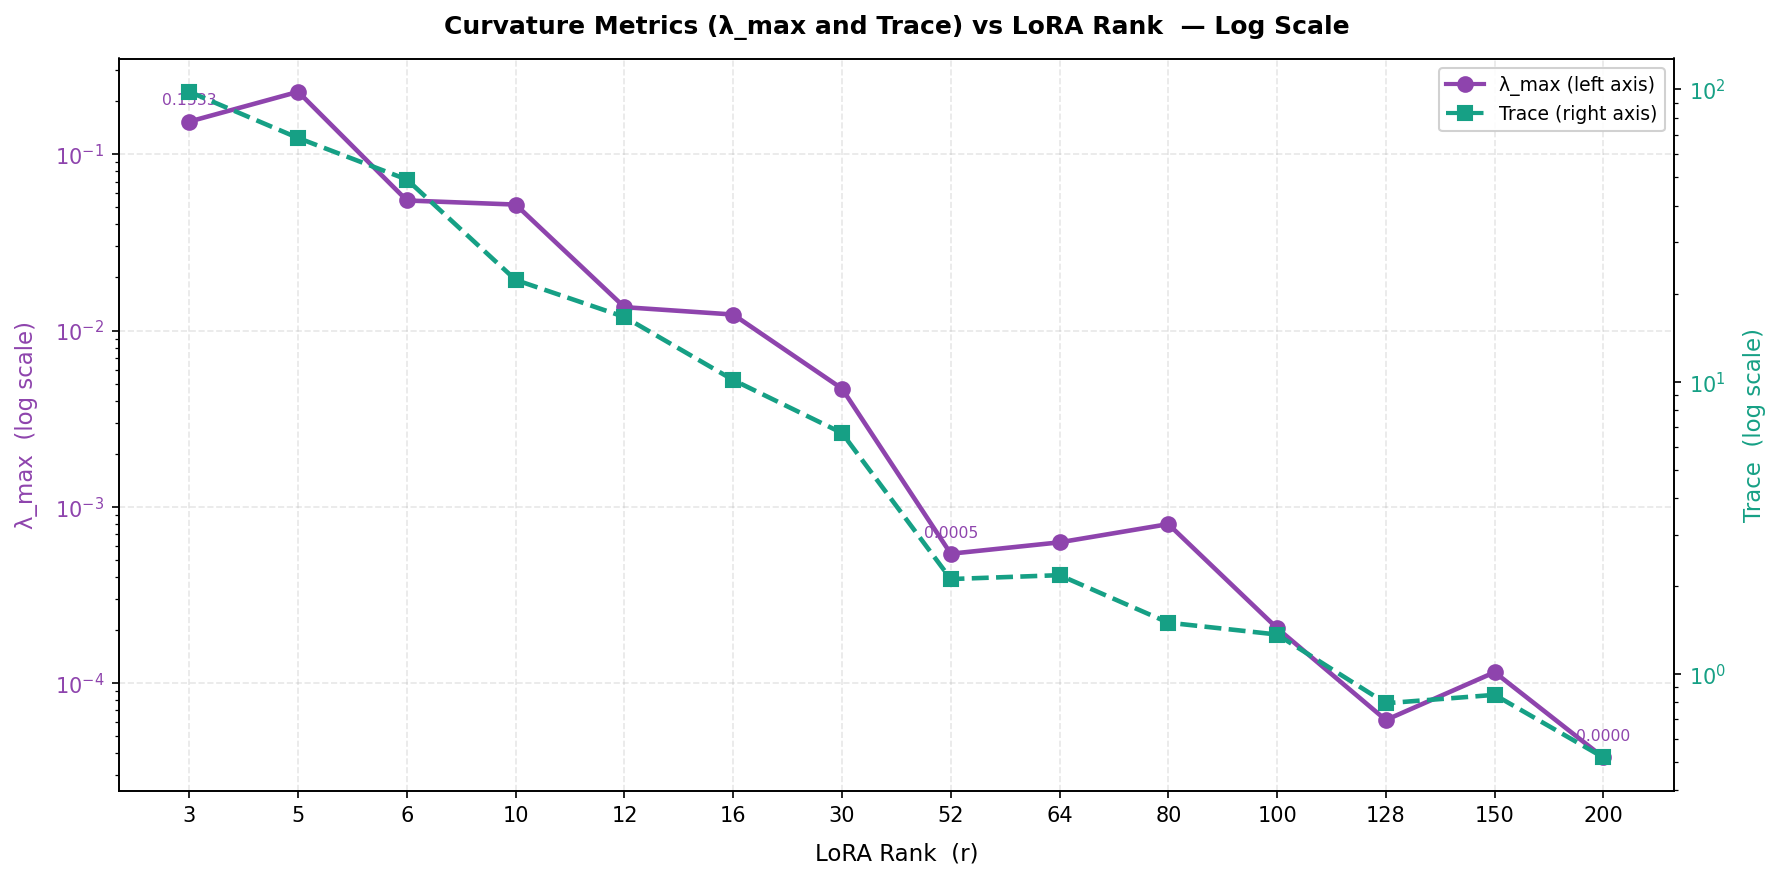

Saved -> ./plots/plot_6_lambda_trace_vs_rank.png


In [2]:
# ----------------------------------------------------------------
# PLOT CELL 2 — Plot 6: λ_max and Trace vs LoRA Rank (log-scale, dual-axis)
# ----------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 6))

C_LMAX  = '#8e44ad'
C_TRACE = '#16a085'
x_pos   = np.arange(len(valid_ranks))
xlabels = [str(r) for r in valid_ranks]

# λ_max — left axis
ax1.semilogy(x_pos, lmaxs, color=C_LMAX, marker='o', linewidth=2.2,
             markersize=7, label='λ_max (max Fisher)', zorder=3)
ax1.set_ylabel('λ_max  (log scale)', color=C_LMAX, labelpad=8)
ax1.tick_params(axis='y', labelcolor=C_LMAX)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(xlabels)
ax1.set_xlabel('LoRA Rank  (r)', labelpad=8)
ax1.grid(True, axis='both', linestyle='--', alpha=0.3)

# Trace — right axis
ax2 = ax1.twinx()
ax2.semilogy(x_pos, traces, color=C_TRACE, marker='s', linewidth=2.2,
             markersize=7, linestyle='--', label='Trace (total Fisher)', zorder=3)
ax2.set_ylabel('Trace  (log scale)', color=C_TRACE, labelpad=8)
ax2.tick_params(axis='y', labelcolor=C_TRACE)

# Legend
legend_elements = [
    Line2D([0],[0], color=C_LMAX,  marker='o', linewidth=2, markersize=7, label='λ_max (left axis)'),
    Line2D([0],[0], color=C_TRACE, marker='s', linewidth=2, markersize=7, linestyle='--', label='Trace (right axis)'),
]
ax1.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
ax1.set_title('Curvature Metrics (λ_max and Trace) vs LoRA Rank  — Log Scale',
              fontsize=12, fontweight='bold', pad=12)

# Annotate key values
for i, r in enumerate(valid_ranks):
    if r in [3, 52, 200]:
        ax1.annotate(f'{lmaxs[i]:.4f}', (x_pos[i], lmaxs[i]),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=7.5, color=C_LMAX)

plt.tight_layout()
out_path = f'{PLOTS_DIR}/plot_6_lambda_trace_vs_rank.png'
fig.savefig(out_path)
plt.show()
print(f'Saved -> {out_path}')


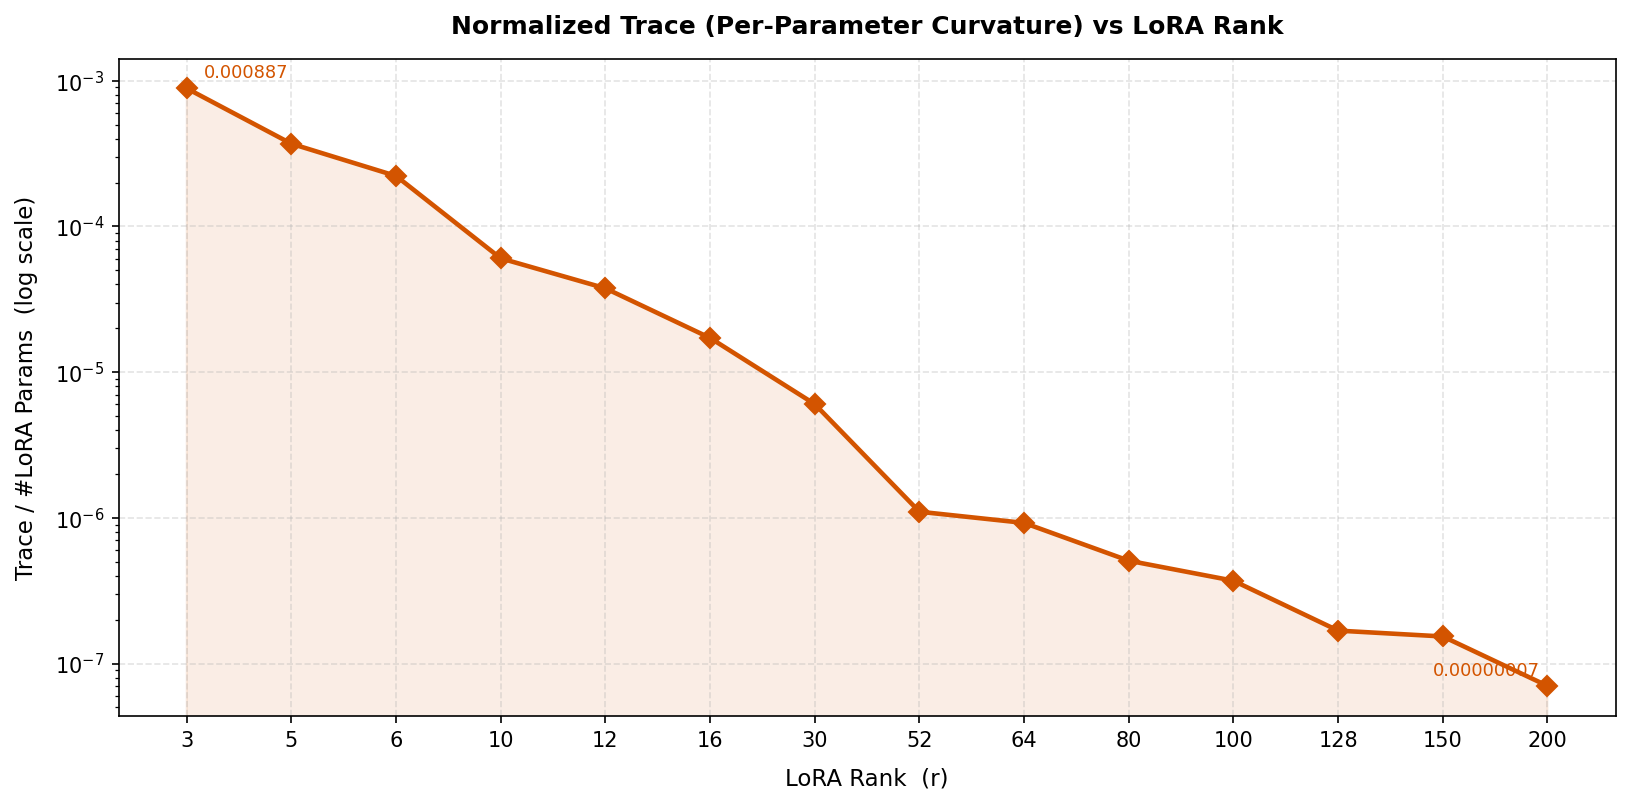

Saved -> ./plots/plot_7_normalized_trace_vs_rank.png


In [9]:
# ----------------------------------------------------------------
# PLOT CELL 3 — Plot 7: Normalized Trace (Trace/Param) vs LoRA Rank (log scale)
# ----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.5))

C_TN = '#d35400'

ax.semilogy(np.arange(len(valid_ranks)), tr_norm,
            color=C_TN, marker='D', linewidth=2.2, markersize=7, zorder=3)
ax.fill_between(np.arange(len(valid_ranks)), tr_norm, alpha=0.1, color=C_TN)

ax.set_xticks(np.arange(len(valid_ranks)))
ax.set_xticklabels([str(r) for r in valid_ranks])
ax.set_xlabel('LoRA Rank  (r)', labelpad=8)
ax.set_ylabel('Trace / #LoRA Params  (log scale)', labelpad=8)
ax.set_title('Normalized Trace (Per-Parameter Curvature) vs LoRA Rank',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(True, axis='both', linestyle='--', alpha=0.35)

# Annotate the drop factor
drop_factor = tr_norm[0] / tr_norm[-1]
# ax.annotate('',
#             xy  =(len(valid_ranks)-1, tr_norm[-1]),
#             xytext=(0, tr_norm[0]),
#             arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5, linestyle='dashed'))
# ax.text(6.5, tr_norm[6], f'{drop_factor:.0f}× drop\nr={valid_ranks[0]}→r={valid_ranks[-1]}',
        # fontsize=9.5, color='#888888', style='italic', ha='center')

# Annotate first and last values
ax.annotate(f'{tr_norm[0]:.6f}', (0, tr_norm[0]),
            textcoords='offset points', xytext=(8, 5), fontsize=8.5, color=C_TN)
ax.annotate(f'{tr_norm[-1]:.8f}', (len(valid_ranks)-1, tr_norm[-1]),
            textcoords='offset points', xytext=(-55, 5), fontsize=8.5, color=C_TN)

plt.tight_layout()
out_path = f'{PLOTS_DIR}/plot_7_normalized_trace_vs_rank.png'
fig.savefig(out_path)
plt.show()
print(f'Saved -> {out_path}')


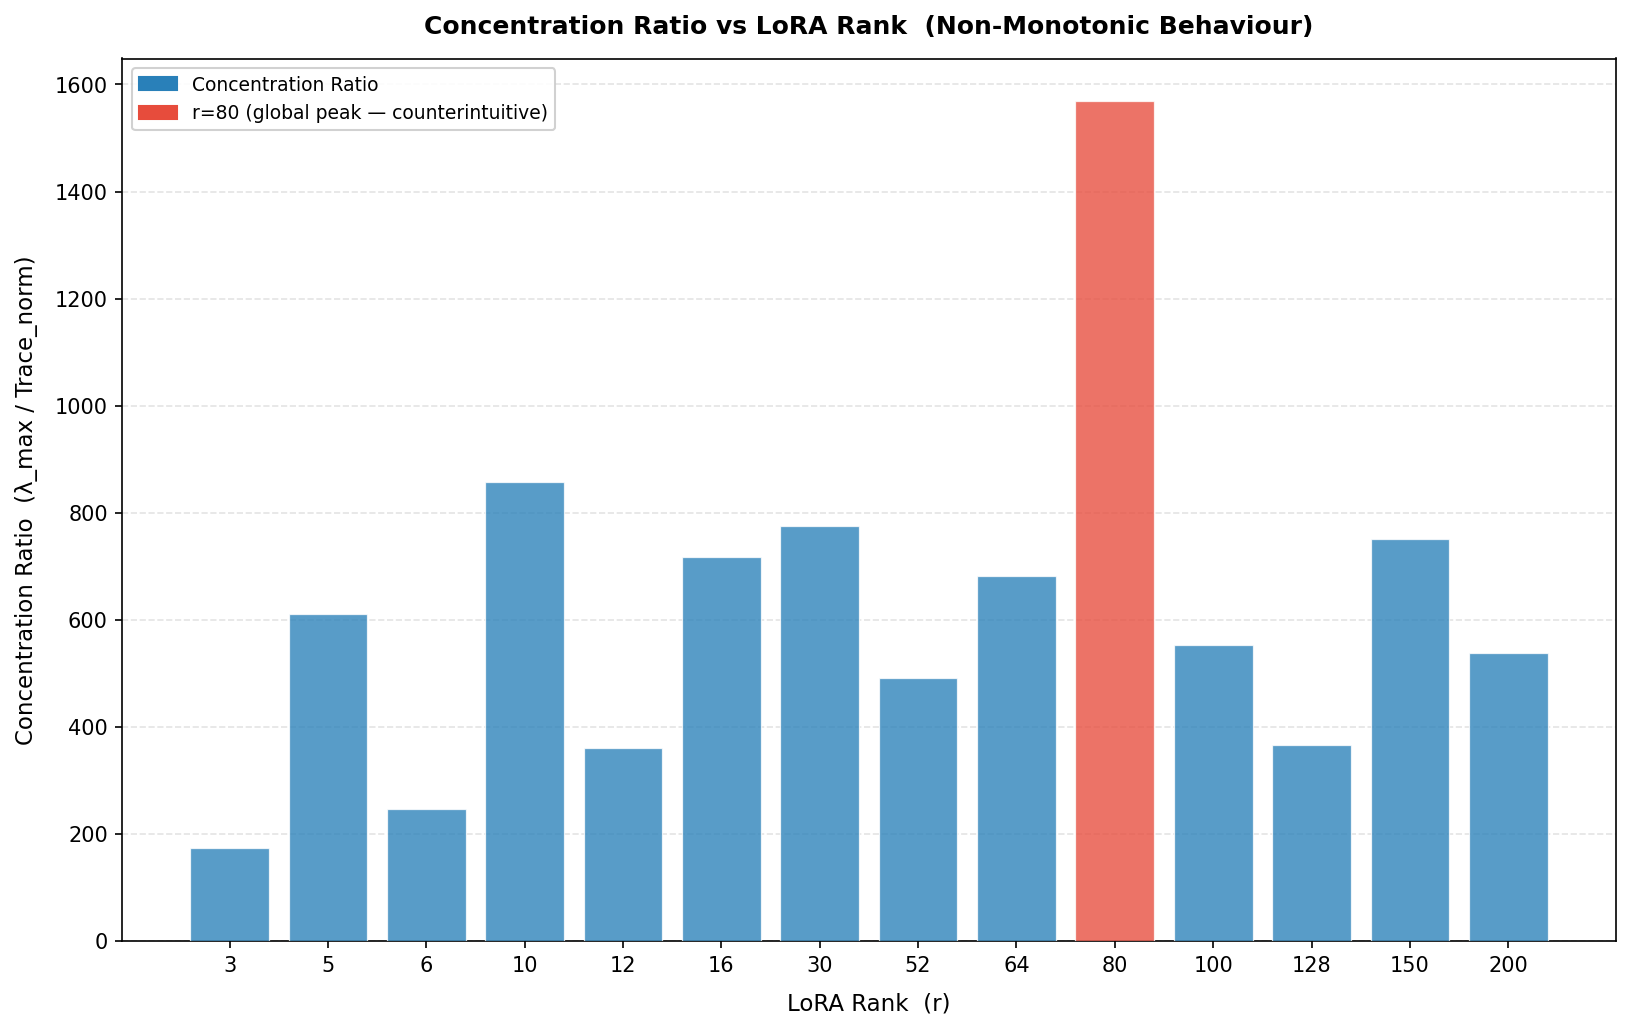

Saved -> ./plots/plot_8_concentration_ratio_vs_rank.png


In [17]:
# ----------------------------------------------------------------
# PLOT CELL 4 — Plot 8: Concentration Ratio vs LoRA Rank
# Non-monotonic behaviour highlighted (r=80 peak)
# ----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

C_CR    = '#2980b9'
C_PEAK  = '#e74c3c'

x_pos = np.arange(len(valid_ranks))

bar_colors = [C_PEAK if r == 80 else C_CR for r in valid_ranks]
bars = ax.bar(x_pos, conc_rat, color=bar_colors, alpha=0.78, zorder=3,
              edgecolor='white', linewidth=0.6)
# ax.plot(x_pos, conc_rat, color='#1a252f', marker='o', linewidth=1.5,
        # # markersize=5, zorder=4, alpha=0.75)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(r) for r in valid_ranks])
ax.set_xlabel('LoRA Rank  (r)', labelpad=8)
ax.set_ylabel('Concentration Ratio  (λ_max / Trace_norm)', labelpad=8)
ax.set_title('Concentration Ratio vs LoRA Rank  (Non-Monotonic Behaviour)',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.35)

# Annotate r=80 peak
peak_idx = valid_ranks.index(80)
# ax.annotate(f'Peak: r=80\n({conc_rat[peak_idx]:.0f})',
#             (peak_idx, conc_rat[peak_idx]),
#             textcoords='offset points', xytext=(5, 8),
#             fontsize=9, color=C_PEAK, fontweight='bold',
#             arrowprops=dict(arrowstyle='->', color=C_PEAK, lw=1.2))

legend_patches = [
    mpatches.Patch(color=C_CR,   label='Concentration Ratio'),
    mpatches.Patch(color=C_PEAK, label='r=80 (global peak — counterintuitive)'),
]
ax.legend(handles=legend_patches, loc='upper left', framealpha=0.9)

plt.tight_layout()
out_path = f'{PLOTS_DIR}/plot_8_concentration_ratio_vs_rank.png'
fig.savefig(out_path)
plt.show()
print(f'Saved -> {out_path}')


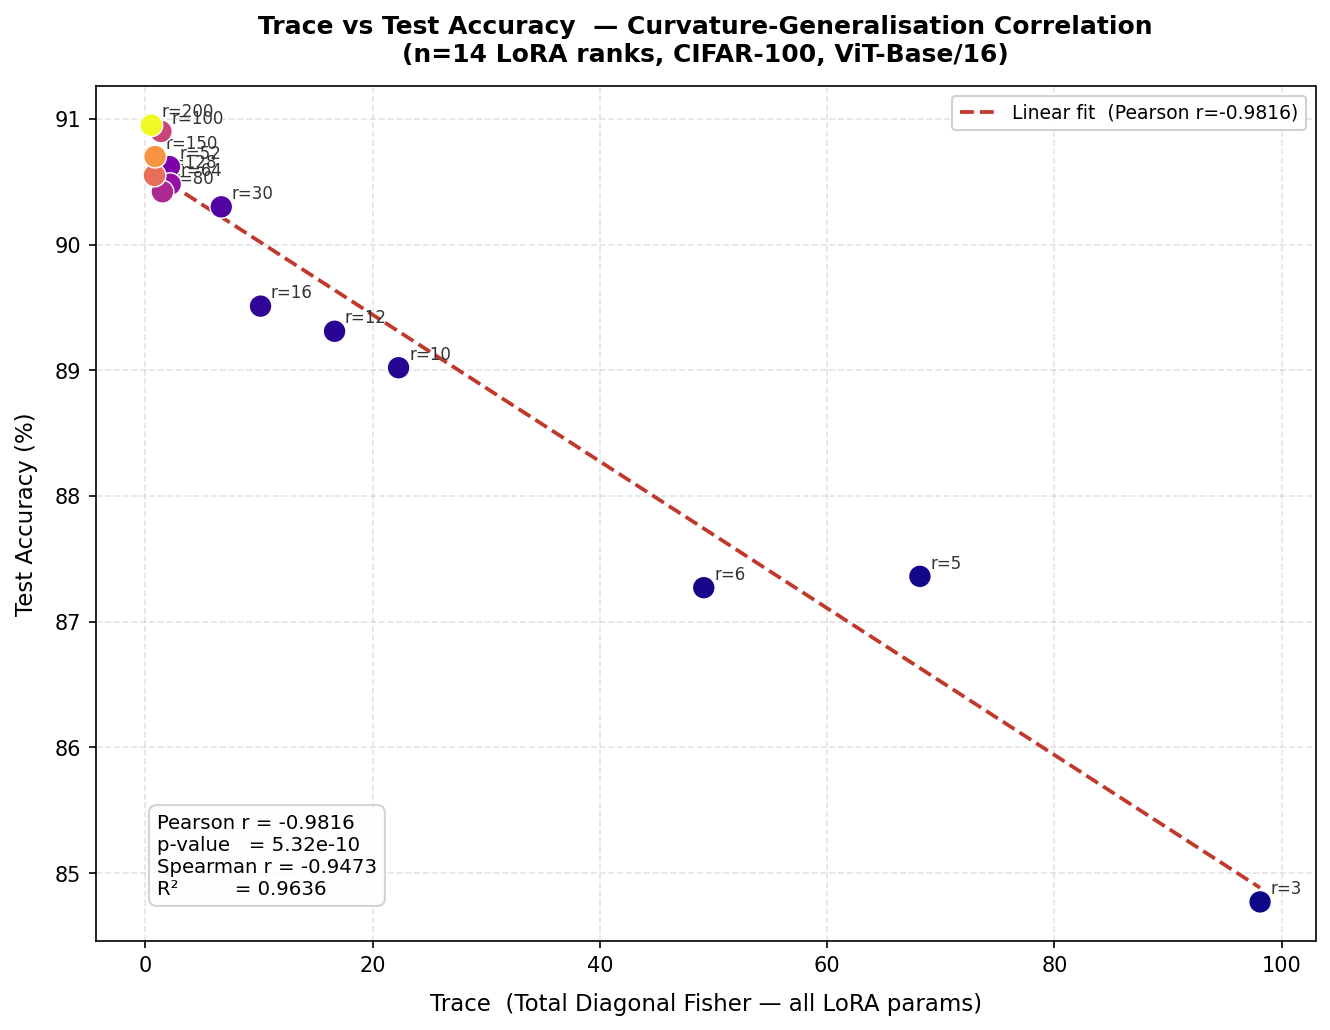

Saved -> ./plots/plot_9_trace_vs_accuracy_regression.png
Pearson r=-0.9816  p=5.32e-10  R²=0.9636  Spearman r=-0.9473


In [22]:
# ----------------------------------------------------------------
# PLOT CELL 5 — Plot 9: Trace vs Test Accuracy Scatter + Regression
# Key correlation proof: Pearson r = -0.9816, R² = 0.9636
# ----------------------------------------------------------------
from scipy.stats import pearsonr, spearmanr

fig, ax = plt.subplots(figsize=(9, 7))

C_POINTS = '#16a085'
C_REG    = '#c0392b'

# Pearson + Spearman
p_r, p_pval = pearsonr(traces, accs)
s_r, s_pval = spearmanr(traces, accs)
r2 = p_r ** 2

# Regression line
slope, intercept, _, _, _ = linregress(traces, accs)
x_line = np.linspace(min(traces), max(traces), 200)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color=C_REG, linewidth=1.8, linestyle='--',
        label=f'Linear fit  (Pearson r={p_r:.4f})', zorder=2)

# Scatter
ax.scatter(traces, accs, c=valid_ranks, cmap='plasma',
           s=120, zorder=4, edgecolors='white', linewidths=0.7)

# Annotate each point with rank
for i, r in enumerate(valid_ranks):
    ax.annotate(f'r={r}', (traces[i], accs[i]),
                textcoords='offset points', xytext=(5, 4),
                fontsize=8, color='#333')

# Stats box
stats_text = (
    f'Pearson r = {p_r:.4f}\n'
    f'p-value   = {p_pval:.2e}\n'
    f'Spearman r = {s_r:.4f}\n'
    f'R²         = {r2:.4f}'
)
ax.text(0.05, 0.05, stats_text,
        transform=ax.transAxes, fontsize=9.5,
        verticalalignment='bottom', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdfefe', alpha=0.85,
                  edgecolor='#cccccc'))

ax.set_xlabel('Trace  (Total Diagonal Fisher — all LoRA params)', labelpad=8)
ax.set_ylabel('Test Accuracy (%)', labelpad=8)
ax.set_title('Trace vs Test Accuracy  — Curvature-Generalisation Correlation\n(n=14 LoRA ranks, CIFAR-100, ViT-Base/16)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
out_path = f'{PLOTS_DIR}/plot_9_trace_vs_accuracy_regression.png'
fig.savefig(out_path)
plt.show()
print(f'Saved -> {out_path}')
print(f'Pearson r={p_r:.4f}  p={p_pval:.2e}  R²={r2:.4f}  Spearman r={s_r:.4f}')


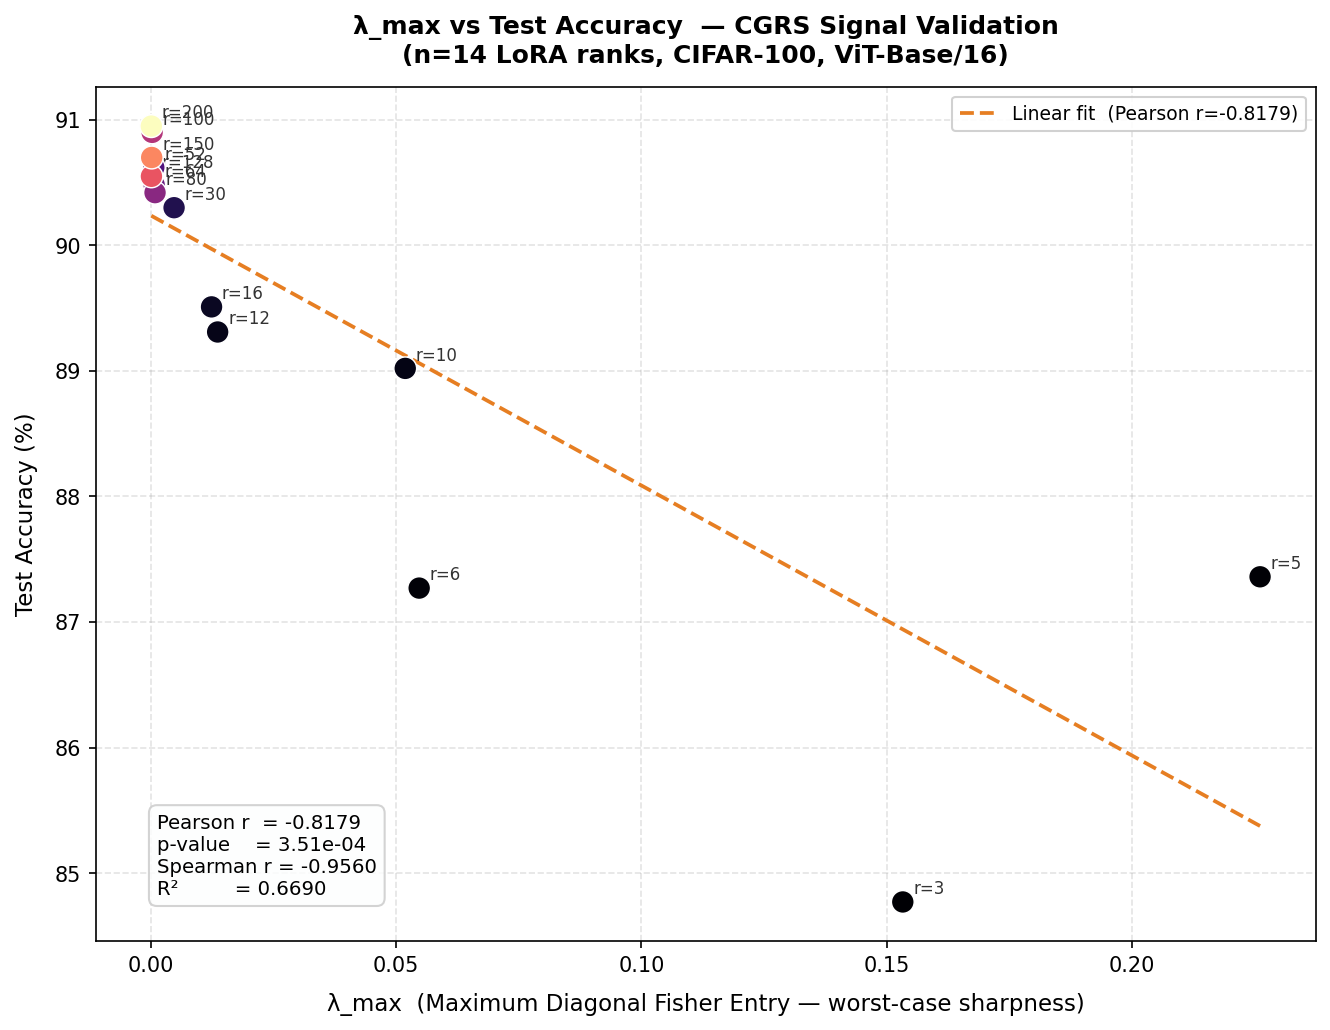

Saved -> ./plots/plot_10_lmax_vs_accuracy_regression.png
Pearson r=-0.8179  p=3.51e-04  R²=0.6690  Spearman r=-0.9560


In [24]:
# ----------------------------------------------------------------
# PLOT CELL 6 — Plot 10: λ_max vs Test Accuracy Scatter + Regression
# CGRS signal: Pearson r = -0.8179, Spearman r = -0.9560
# ----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))

C_POINTS = '#8e44ad'
C_REG    = '#e67e22'

p_r, p_pval = pearsonr(lmaxs, accs)
s_r, s_pval = spearmanr(lmaxs, accs)
r2 = p_r ** 2

slope, intercept, _, _, _ = linregress(lmaxs, accs)
x_line = np.linspace(min(lmaxs), max(lmaxs), 200)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color=C_REG, linewidth=1.8, linestyle='--',
        label=f'Linear fit  (Pearson r={p_r:.4f})', zorder=2)

ax.scatter(lmaxs, accs, c=valid_ranks, cmap='magma',
           s=120, zorder=4, edgecolors='white', linewidths=0.7)

for i, r in enumerate(valid_ranks):
    ax.annotate(f'r={r}', (lmaxs[i], accs[i]),
                textcoords='offset points', xytext=(5, 4),
                fontsize=8, color='#333')

stats_text = (
    f'Pearson r  = {p_r:.4f}\n'
    f'p-value    = {p_pval:.2e}\n'
    f'Spearman r = {s_r:.4f}\n'
    f'R²         = {r2:.4f}'
)
ax.text(0.05, 0.05, stats_text,
        transform=ax.transAxes, fontsize=9.5,
        verticalalignment='bottom', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdfefe', alpha=0.85,
                  edgecolor='#cccccc'))

ax.set_xlabel('λ_max  (Maximum Diagonal Fisher Entry — worst-case sharpness)', labelpad=8)
ax.set_ylabel('Test Accuracy (%)', labelpad=8)
ax.set_title('λ_max vs Test Accuracy  — CGRS Signal Validation\n(n=14 LoRA ranks, CIFAR-100, ViT-Base/16)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
out_path = f'{PLOTS_DIR}/plot_10_lmax_vs_accuracy_regression.png'
fig.savefig(out_path)
plt.show()
print(f'Saved -> {out_path}')
print(f'Pearson r={p_r:.4f}  p={p_pval:.2e}  R²={r2:.4f}  Spearman r={s_r:.4f}')


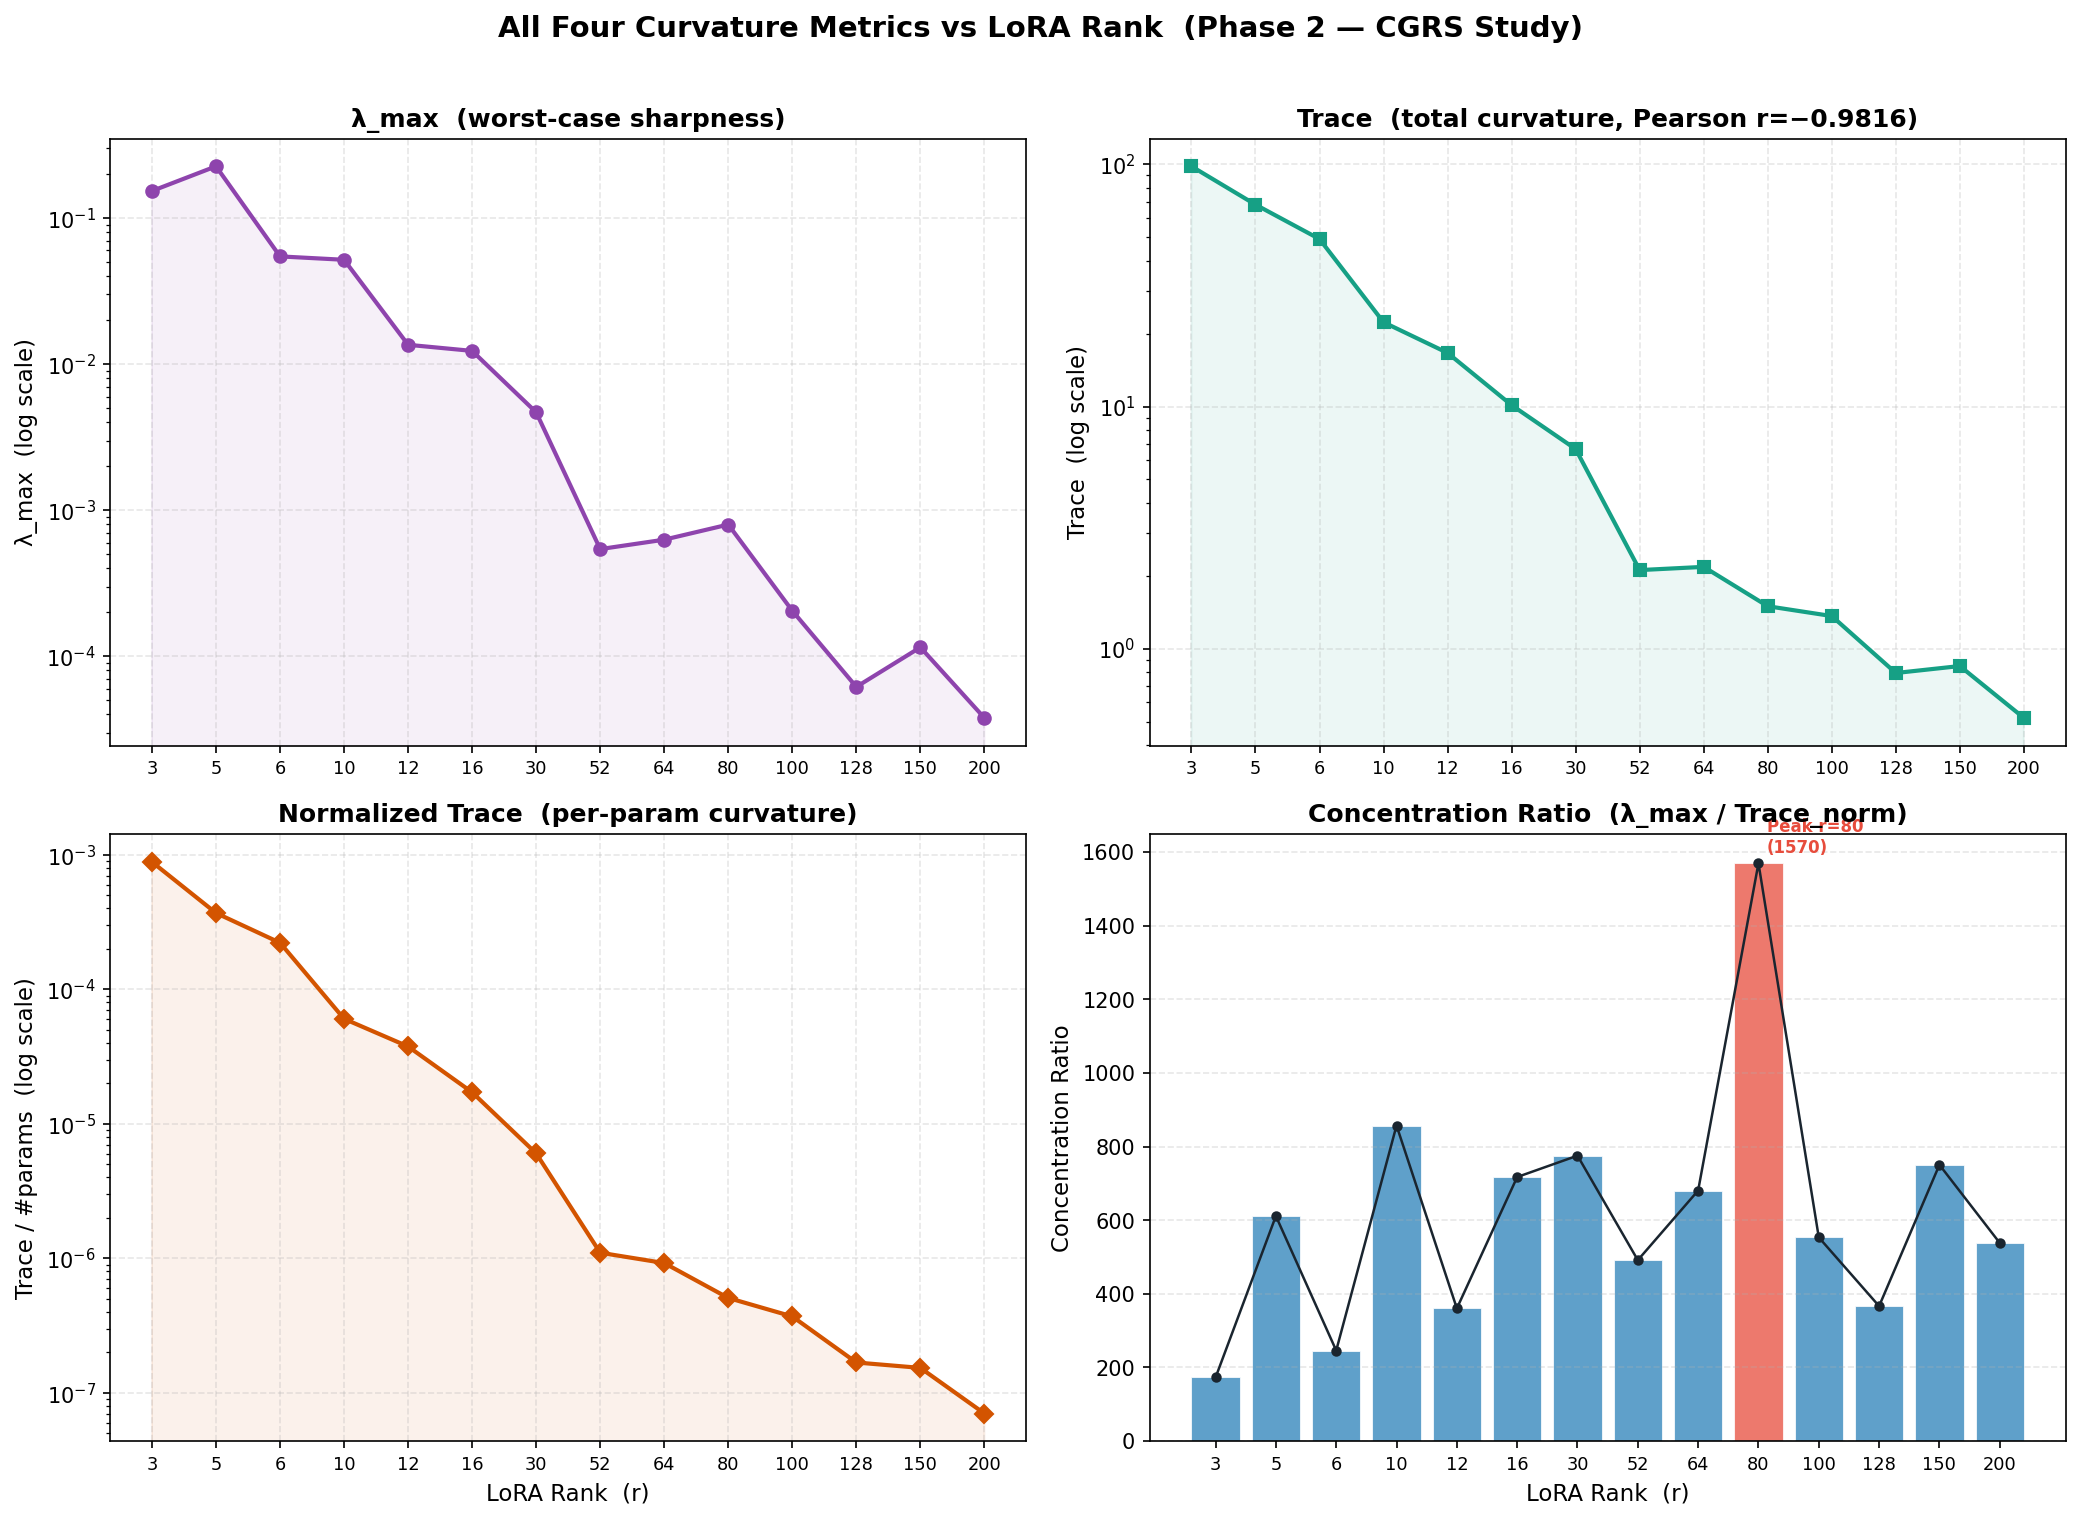

Saved -> ./plots/plot_11_2x2_all_curvature_metrics.png


In [25]:
# ----------------------------------------------------------------
# PLOT CELL 7 — Plot 11: 2x2 Multi-Panel — All Four Curvature Metrics vs Rank
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_pos   = np.arange(len(valid_ranks))
xlabels = [str(r) for r in valid_ranks]

COLORS = ['#8e44ad', '#16a085', '#d35400', '#2980b9']

# --- Panel 1: λ_max (log) ---
ax = axes[0, 0]
ax.semilogy(x_pos, lmaxs, color=COLORS[0], marker='o', linewidth=2, markersize=6)
ax.fill_between(x_pos, lmaxs, alpha=0.08, color=COLORS[0])
ax.set_title('λ_max  (worst-case sharpness)', fontweight='bold')
ax.set_ylabel('λ_max  (log scale)')
ax.set_xticks(x_pos); ax.set_xticklabels(xlabels, fontsize=8.5)
ax.grid(True, linestyle='--', alpha=0.3)

# --- Panel 2: Trace (log) ---
ax = axes[0, 1]
ax.semilogy(x_pos, traces, color=COLORS[1], marker='s', linewidth=2, markersize=6)
ax.fill_between(x_pos, traces, alpha=0.08, color=COLORS[1])
ax.set_title('Trace  (total curvature, Pearson r=−0.9816)', fontweight='bold')
ax.set_ylabel('Trace  (log scale)')
ax.set_xticks(x_pos); ax.set_xticklabels(xlabels, fontsize=8.5)
ax.grid(True, linestyle='--', alpha=0.3)

# --- Panel 3: Normalized Trace (log) ---
ax = axes[1, 0]
ax.semilogy(x_pos, tr_norm, color=COLORS[2], marker='D', linewidth=2, markersize=6)
ax.fill_between(x_pos, tr_norm, alpha=0.08, color=COLORS[2])
ax.set_title('Normalized Trace  (per-param curvature)', fontweight='bold')
ax.set_ylabel('Trace / #params  (log scale)')
ax.set_xlabel('LoRA Rank  (r)')
ax.set_xticks(x_pos); ax.set_xticklabels(xlabels, fontsize=8.5)
ax.grid(True, linestyle='--', alpha=0.3)

# --- Panel 4: Concentration Ratio ---
ax = axes[1, 1]
bar_colors_cr = ['#e74c3c' if r == 80 else COLORS[3] for r in valid_ranks]
ax.bar(x_pos, conc_rat, color=bar_colors_cr, alpha=0.75, edgecolor='white', linewidth=0.5)
ax.plot(x_pos, conc_rat, color='#1a252f', marker='o', linewidth=1.2, markersize=4, zorder=3)
ax.set_title('Concentration Ratio  (λ_max / Trace_norm)', fontweight='bold')
ax.set_ylabel('Concentration Ratio')
ax.set_xlabel('LoRA Rank  (r)')
ax.set_xticks(x_pos); ax.set_xticklabels(xlabels, fontsize=8.5)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
peak_idx = valid_ranks.index(80)
ax.annotate(f'Peak r=80\n({conc_rat[peak_idx]:.0f})',
            (peak_idx, conc_rat[peak_idx]),
            textcoords='offset points', xytext=(4, 5),
            fontsize=8, color='#e74c3c', fontweight='bold')

fig.suptitle('All Four Curvature Metrics vs LoRA Rank  (Phase 2 — CGRS Study)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = f'{PLOTS_DIR}/plot_11_2x2_all_curvature_metrics.png'
fig.savefig(out_path)
plt.show()
print(f'Saved -> {out_path}')


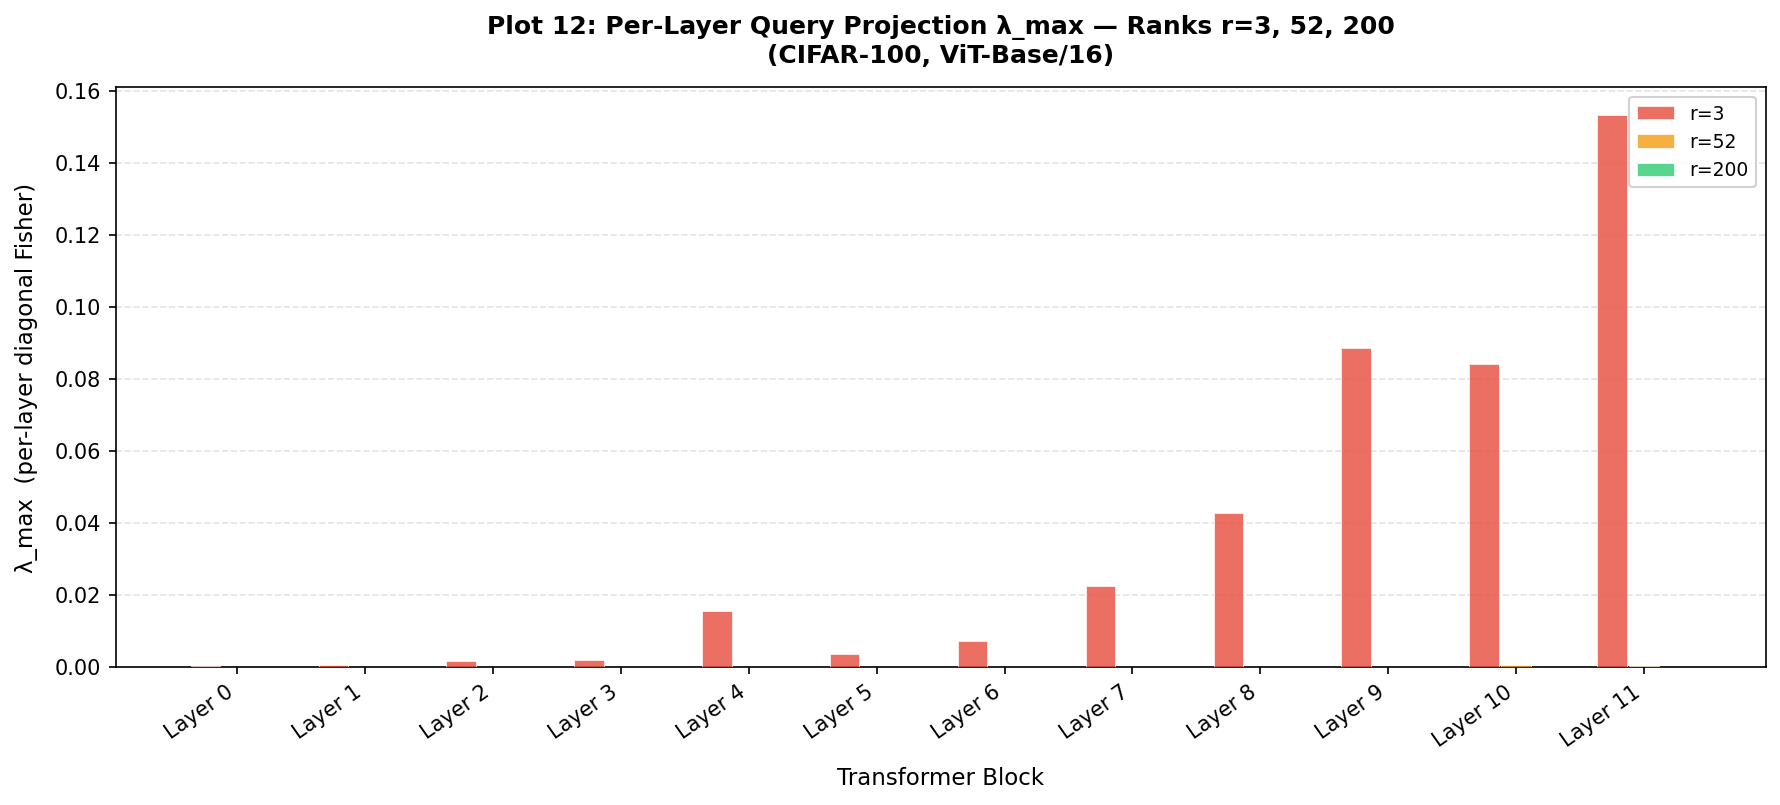

Saved -> ./plots/plot_12_perlayer_query_lmax.png


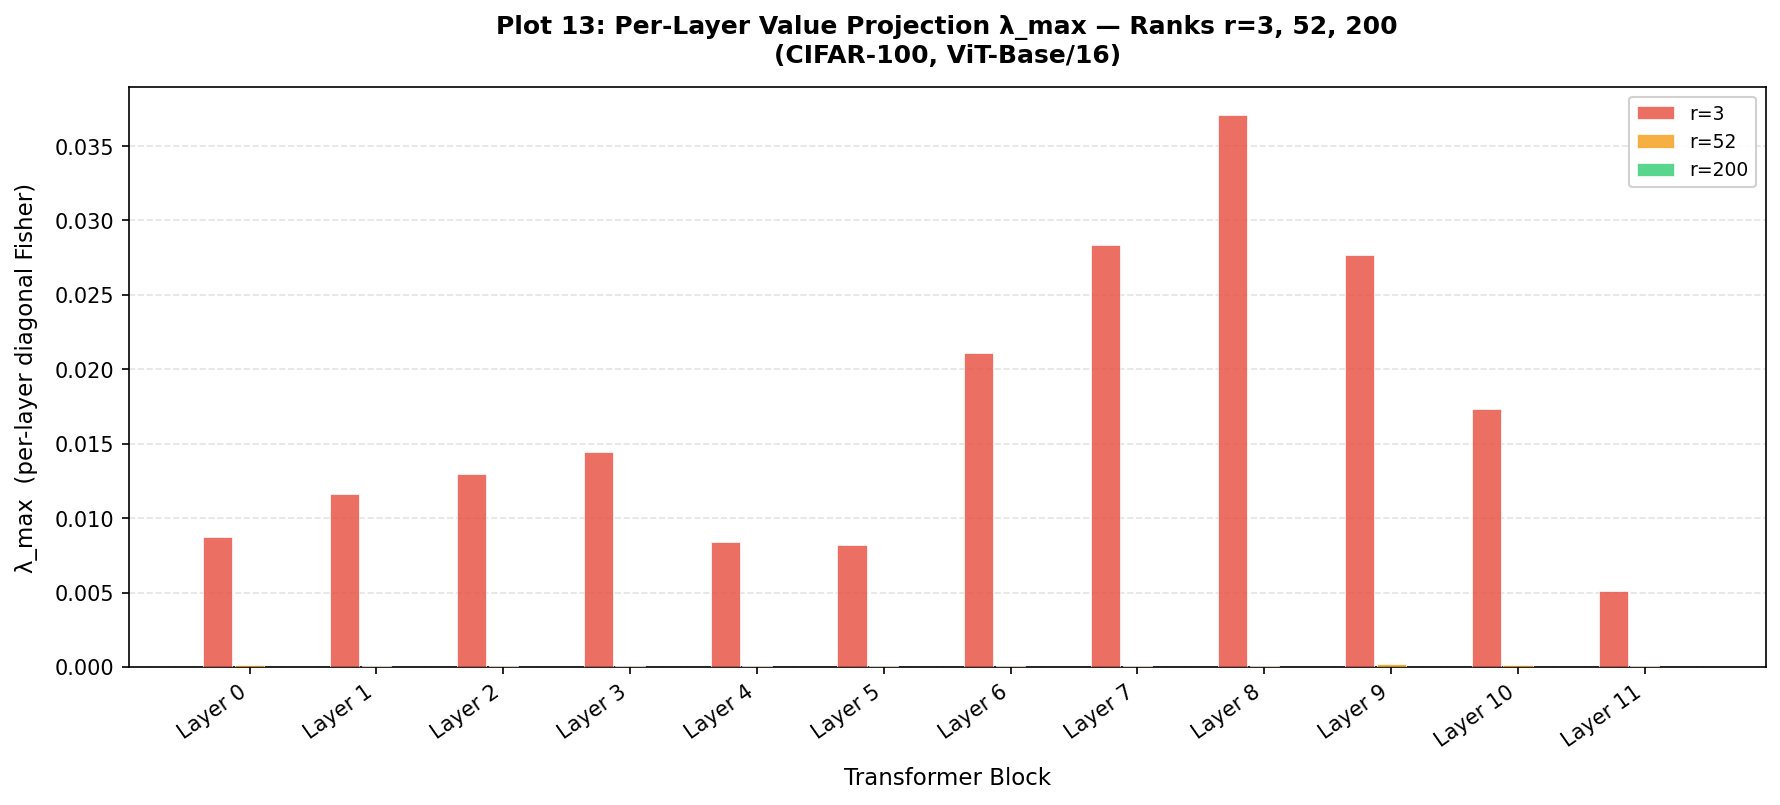

Saved -> ./plots/plot_13_perlayer_value_lmax.png


In [26]:
# ----------------------------------------------------------------
# PLOT CELL 8 — Plots 12 & 13: Per-Layer Query and Value λ_max
# Representative ranks: r=3, r=52, r=200
# Requires per-layer data in curvature_results.json.
# ----------------------------------------------------------------

REP_RANKS = [r for r in [3, 52, 200] if r in valid_ranks
             and bool(per_layer.get(r, {}))]

if not REP_RANKS:
    print('No per-layer data found in curvature_results.json.')
    print('Per-layer data is stored under the "per_layer" key per rank.')
    print('If your curvature_results.json stores per-layer data differently,')
    print('check the key structure and adjust the parsing below accordingly.')
else:
    N_LAYERS = 12
    layer_ids = list(range(N_LAYERS))

    def get_layer_lmax(rank, module):
        """Parse per-layer λ_max for a given rank and module ('query' or 'value')."""
        layer_data = per_layer.get(rank, {})
        vals = []
        for lid in range(N_LAYERS):
            key = str((lid, module))
            if key in layer_data:
                vals.append(layer_data[key].get('lambda_max', 0.0))
            else:
                vals.append(0.0)
        return vals

    for module, plot_num in [('query', 12), ('value', 13)]:
        fig, ax = plt.subplots(figsize=(12, 5.5))

        width   = 0.25
        rep_colors = ['#e74c3c', '#f39c12', '#2ecc71']
        x = np.arange(N_LAYERS)

        for i, r in enumerate(REP_RANKS):
            vals = get_layer_lmax(r, module)
            offset = (i - len(REP_RANKS)/2 + 0.5) * width
            ax.bar(x + offset, vals, width=width * 0.92,
                   color=rep_colors[i], alpha=0.80,
                   label=f'r={r}', edgecolor='white', linewidth=0.4, zorder=3)

        ax.set_xticks(x)
        ax.set_xticklabels([f'Layer {i}' for i in range(N_LAYERS)], rotation=35, ha='right')
        ax.set_xlabel('Transformer Block', labelpad=8)
        ax.set_ylabel('λ_max  (per-layer diagonal Fisher)', labelpad=8)
        ax.set_title(
            f'Plot {plot_num}: Per-Layer {module.capitalize()} Projection λ_max — '
            f'Ranks r=3, 52, 200\n(CIFAR-100, ViT-Base/16)',
            fontweight='bold', pad=12
        )
        ax.legend(loc='upper right', framealpha=0.9)
        ax.grid(True, axis='y', linestyle='--', alpha=0.35)

        plt.tight_layout()
        fname = f'query' if module == 'query' else 'value'
        out_path = f'{PLOTS_DIR}/plot_{plot_num}_perlayer_{fname}_lmax.png'
        fig.savefig(out_path)
        plt.show()
        print(f'Saved -> {out_path}')


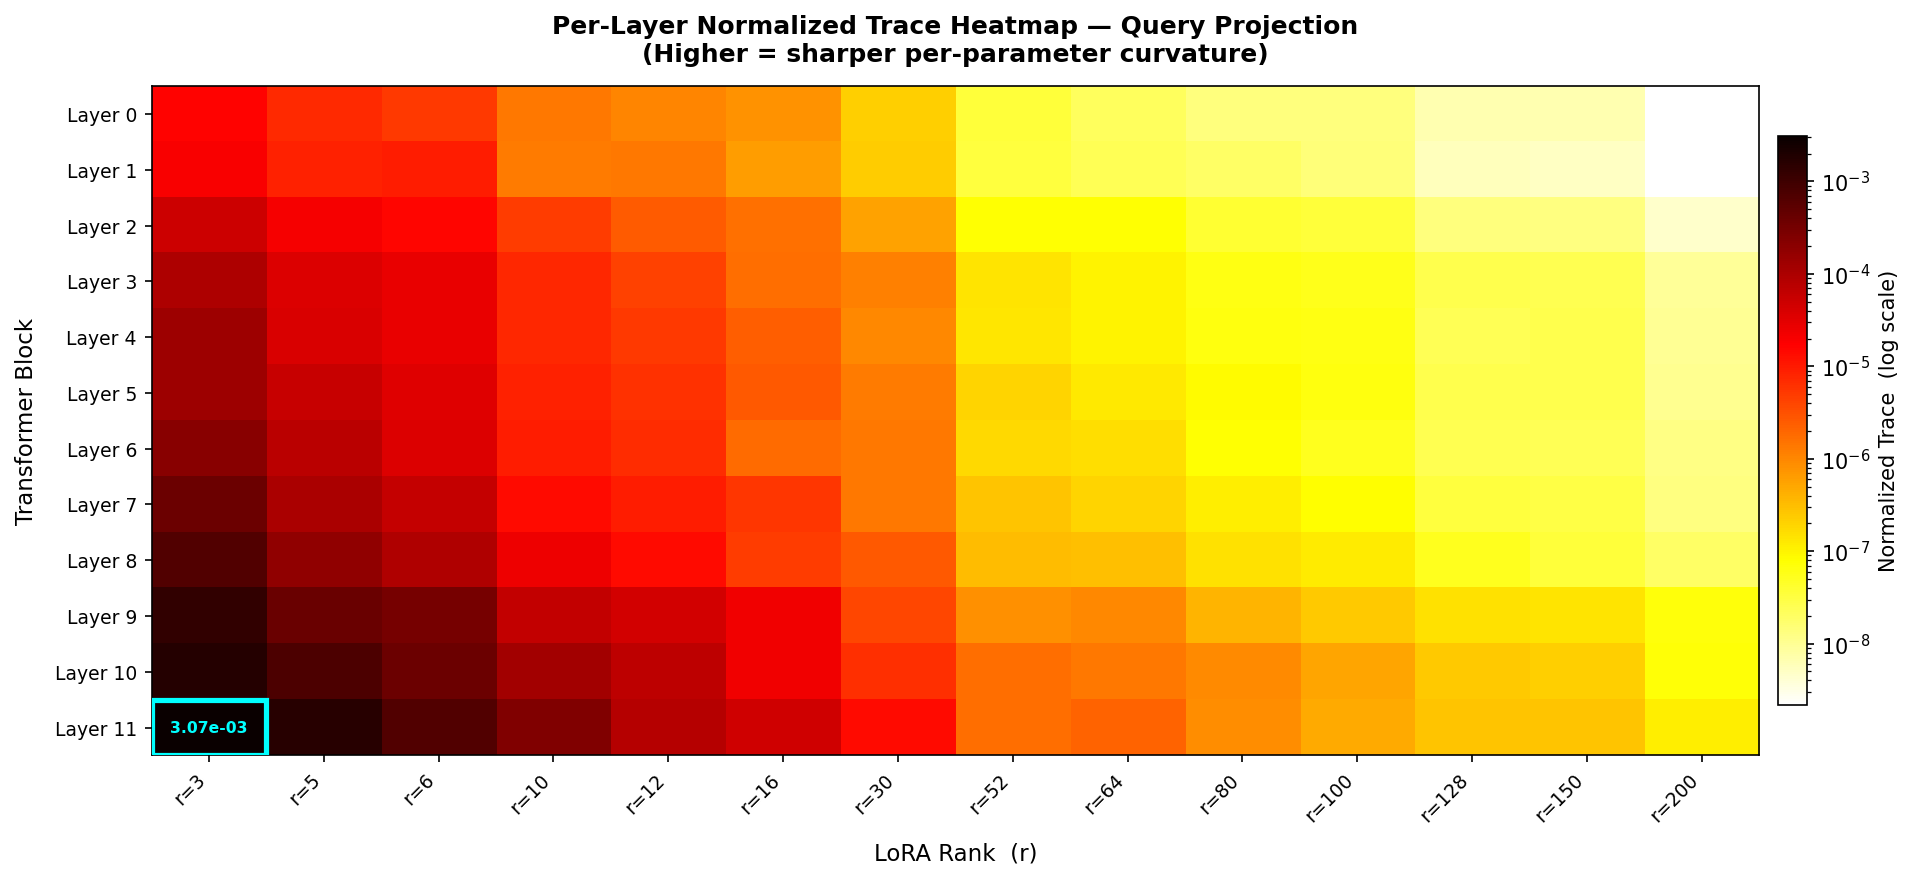

Saved -> ./plots/plot_14_heatmap_normalized_trace_query.png
  Sharpest cell: Layer 11, r=3


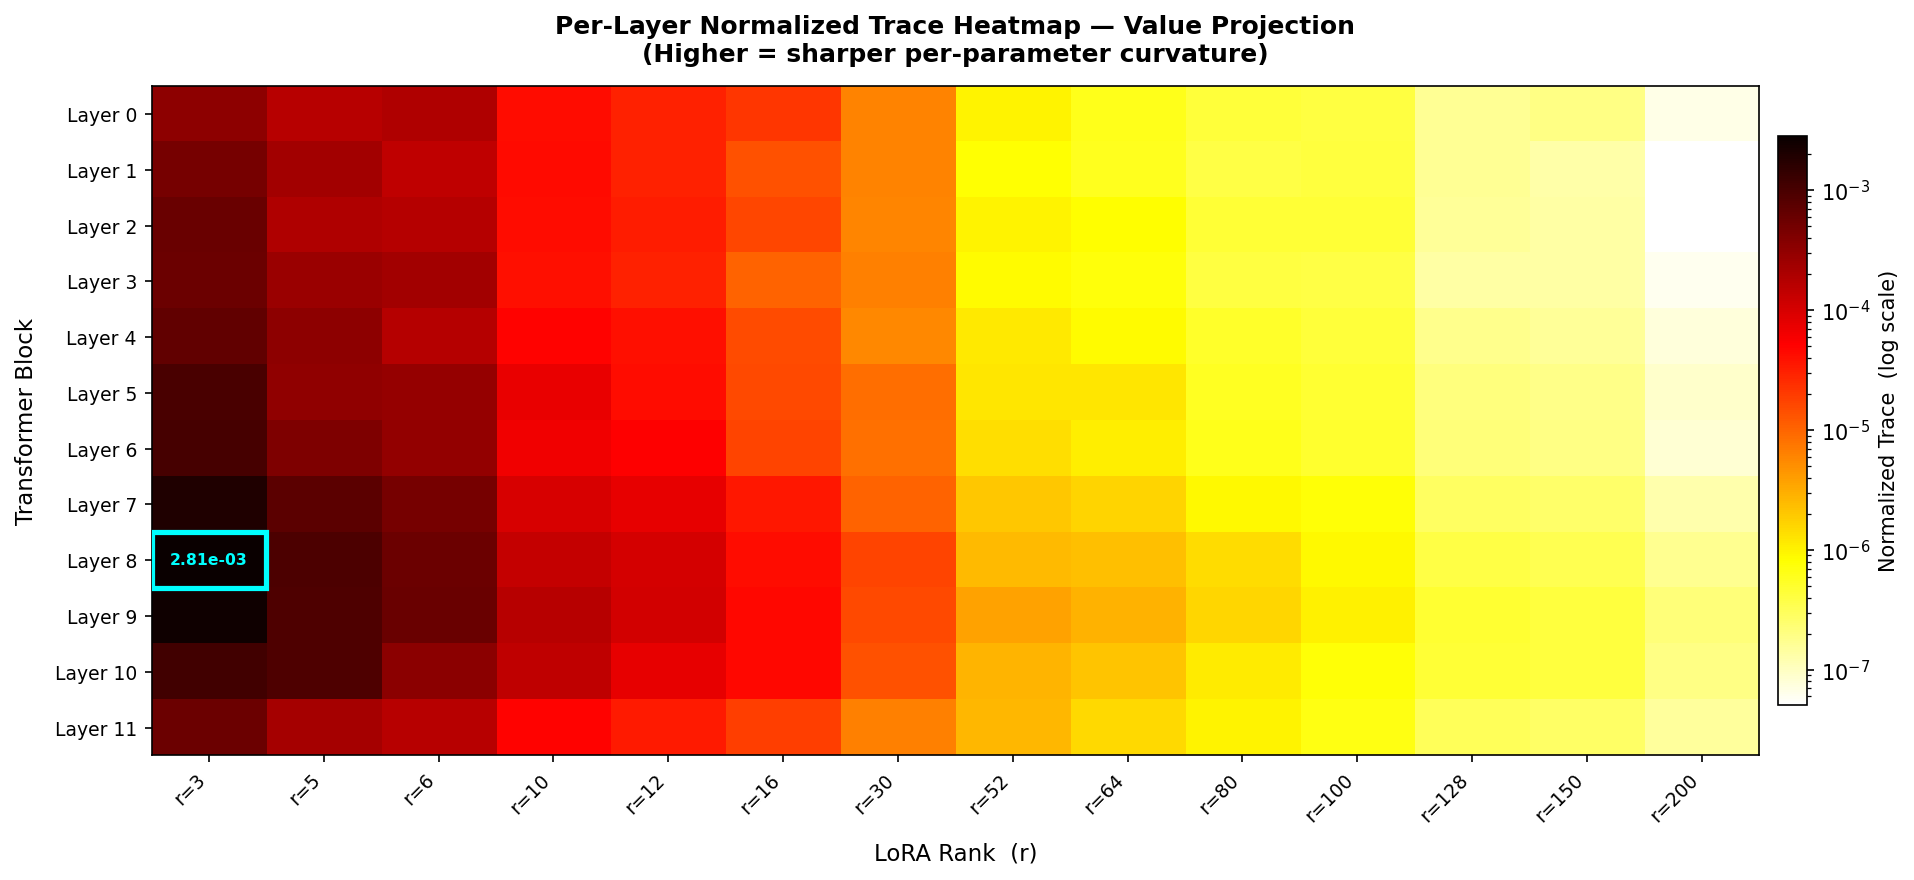

Saved -> ./plots/plot_14_heatmap_normalized_trace_value.png
  Sharpest cell: Layer 8, r=3


In [27]:
# ----------------------------------------------------------------
# PLOT CELL 9 — Plot 14: Per-Layer Normalized Trace Heatmap
# Rows = transformer layers 0-11
# Cols = all valid LoRA ranks
# Color = normalized trace (per-parameter curvature)
# Requires per-layer data in curvature_results.json.
# ----------------------------------------------------------------

import matplotlib.colors as mcolors

N_LAYERS = 12
ranked_valid = [r for r in valid_ranks if bool(per_layer.get(r, {}))]

if not ranked_valid:
    print('No per-layer data found for heatmap.')
    print('Skipping Plot 14. This plot requires per-layer Fisher data')
    print('stored under the "per_layer" key in curvature_results.json.')
else:
    for module in ['query', 'value']:
        heatmap_data = np.zeros((N_LAYERS, len(ranked_valid)))

        for col_idx, r in enumerate(ranked_valid):
            layer_data = per_layer.get(r, {})
            for row_idx in range(N_LAYERS):
                key = str((row_idx, module))
                if key in layer_data:
                    heatmap_data[row_idx, col_idx] = layer_data[key].get('trace_normalized', 0.0)

        # Mask zeros for display
        masked_data = np.ma.masked_where(heatmap_data == 0, heatmap_data)

        fig, ax = plt.subplots(figsize=(14, 6))

        # Log-normalise for visibility across very different magnitudes
        vmin = masked_data[masked_data > 0].min() if masked_data.count() > 0 else 1e-8
        vmax = masked_data.max() if masked_data.count() > 0 else 1.0
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

        im = ax.imshow(masked_data, aspect='auto', cmap='hot_r',
                       norm=norm, interpolation='nearest')

        ax.set_xticks(np.arange(len(ranked_valid)))
        ax.set_xticklabels([f'r={r}' for r in ranked_valid], rotation=45, ha='right', fontsize=9)
        ax.set_yticks(np.arange(N_LAYERS))
        ax.set_yticklabels([f'Layer {i}' for i in range(N_LAYERS)], fontsize=9)
        ax.set_xlabel('LoRA Rank  (r)', labelpad=8)
        ax.set_ylabel('Transformer Block', labelpad=8)
        ax.set_title(
            f'Per-Layer Normalized Trace Heatmap — {module.capitalize()} Projection\n'
            f'(Higher = sharper per-parameter curvature)',
            fontweight='bold', pad=12
        )

        cbar = fig.colorbar(im, ax=ax, pad=0.01, shrink=0.85)
        cbar.set_label('Normalized Trace  (log scale)', fontsize=10)

        # Annotate sharpest cell
        sharpest_idx = np.unravel_index(np.argmax(heatmap_data), heatmap_data.shape)
        ax.add_patch(plt.Rectangle(
            (sharpest_idx[1] - 0.5, sharpest_idx[0] - 0.5),
            1, 1, fill=False, edgecolor='cyan', linewidth=2.5, zorder=5
        ))
        ax.text(sharpest_idx[1], sharpest_idx[0],
                f'{heatmap_data[sharpest_idx]:.2e}',
                ha='center', va='center', fontsize=7.5, color='cyan', fontweight='bold')

        plt.tight_layout()
        out_path = f'{PLOTS_DIR}/plot_14_heatmap_normalized_trace_{module}.png'
        fig.savefig(out_path)
        plt.show()
        print(f'Saved -> {out_path}')
        print(f'  Sharpest cell: Layer {sharpest_idx[0]}, r={ranked_valid[sharpest_idx[1]]}')
